In [1]:
# -*- coding: utf-8 -*-
"""
@author: n0ahb
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import pi, hbar
from scipy.optimize import curve_fit
import numpy.fft as fft
plt.rcParams['text.usetex'] = False

def calculate_energy(psi, X, K, U, kappa, dx, dk, epsilon):

    # make a copy of the wavefunction
    psi_k = np.zeros_like(psi, dtype=complex)
    
    # momentum-space wavefunctions
    for i in range(3):
        psi_k[i] = (dx / dk / nx) ** 0.5 * fft.fft(psi[i])
    
    # kinetic energy
    E_kin = 0
    for i in range(3):
        E_kin += np.sum(np.abs(psi_k[i])**2 * K**2 / 2) * dk
    
    # potential energy
    E_pot = 0
    for i in range(3):
        E_pot += np.sum(np.abs(psi[i])**2 * U[i]) * dx
    
    # interaction energy
    E_int = 0
    n0 = np.abs(psi[0])**2
    n1 = np.abs(psi[1])**2
    n2 = np.abs(psi[2])**2
    
    # Self-interactions
    E_int += kappa[0,0] * np.sum(n0 * n0) * dx / 2
    E_int += kappa[1,1] * np.sum(n1 * n1) * dx / 2
    E_int += kappa[2,2] * np.sum(n2 * n2) * dx / 2
    
    # Cross-interactions
    E_int += kappa[0,1] * np.sum(n0 * n1) * dx
    E_int += kappa[0,2] * np.sum(n0 * n2) * dx
    E_int += kappa[1,2] * np.sum(n1 * n2) * dx
    
    E_total = E_kin + E_pot + E_int
    
    return E_total, E_kin, E_pot, E_int
    
def gpe1d(epsilon, kappa, Omega, N, k, X, U, psi0, Omega_2=0, Ntstore=10, imag_time=0, error=0.0002):
    """
    Three-component GPE solver with coupling structure:
    - comp. 0 couples to comp. 1 w/ strength Omega
    - comp. 1 couples to comp. 2 w/ strength Omega_2
    
    Parameters:
    -----------
    Omega_2 : float
        Coupling strength between components 1 and 2 (default: 0)
    kappa : 3x3 array
        Interaction matrix between all three components
    U : array of length 3
        External potential for each component
    psi0 : array of shape (3, M)
        Initial wavefunctions for all three components
    """
 
    mratio = 1 / (2 + 2**(1/3))
    Ntskip = int(N/(Ntstore-1))
    h = X[1]-X[0]
    M = np.size(X)
    K = fft.fftfreq(M, h) * 2.0 * np.pi
    dk = np.abs(K[1] - K[0])
    T = np.zeros(Ntstore)
    
    # arrays to store energy information
    E_total = np.zeros(Ntstore)
    E_kin = np.zeros(Ntstore)
    E_pot = np.zeros(Ntstore)
    E_int = np.zeros(Ntstore)
    
    if imag_time == 0:
        prefactor = 1j
        psi_out = np.zeros((3, Ntstore, M), complex)
        psi_out[0, 0, :] = psi0[0]
        psi_out[1, 0, :] = psi0[1]
        psi_out[2, 0, :] = psi0[2]
        ep = 0
    else:
        prefactor = 1
        ep = np.zeros(Ntstore)
        psi_out = np.zeros((3, M), complex)
        psiprev = psi0

    # Create 3x3 interaction coefficient matrix
    C = -prefactor * kappa / epsilon
    
    # Create potential array
    U_prop = -prefactor * U / epsilon

    psi = np.array(psi0, dtype=complex)
    
    # Calculate initial energy
    E_total[0], E_kin[0], E_pot[0], E_int[0] = calculate_energy(psi, X, K, U, kappa, h, dk, epsilon)
    
    for t1 in range(Ntstore-1):
        
        for t2 in range(Ntskip):
            
            ######################## First iteration #########################
            
            # Get total density and component densities
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h

            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*mratio/4)*psi[0] - np.sin(Omega*k*mratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*mratio/4)*temp + np.cos(Omega*k*mratio/4)*psi[1]
            
            # Apply half-step coupling propagator (1-2 coupling)
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*mratio/4)*psi[1] - np.sin(Omega_2*k*mratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*mratio/4)*temp + np.cos(Omega_2*k*mratio/4)*psi[2]
            
            # Apply full-step kinetic propagator
            psi[0] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[0]))
            psi[1] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[1]))
            psi[2] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[2]))
            
            # Apply half-step coupling propagator (1-2 coupling) - reverse order
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*mratio/4)*psi[1] - np.sin(Omega_2*k*mratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*mratio/4)*temp + np.cos(Omega_2*k*mratio/4)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*mratio/4)*psi[0] - np.sin(Omega*k*mratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*mratio/4)*temp + np.cos(Omega*k*mratio/4)*psi[1]
            
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h
            
            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[2]
            
            ######################## Second iteration #########################
            
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h
            
            v2ratio = 1 - 2*mratio
            
            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*v2ratio/4)*psi[0] - np.sin(Omega*k*v2ratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*v2ratio/4)*temp + np.cos(Omega*k*v2ratio/4)*psi[1]
            
            # Apply half-step coupling propagator (1-2 coupling)
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*v2ratio/4)*psi[1] - np.sin(Omega_2*k*v2ratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*v2ratio/4)*temp + np.cos(Omega_2*k*v2ratio/4)*psi[2]
            
            # Apply full-step kinetic propagator
            psi[0] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*v2ratio)*fft.fft(psi[0]))
            psi[1] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*v2ratio)*fft.fft(psi[1]))
            psi[2] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*v2ratio)*fft.fft(psi[2]))
            
            # Apply half-step coupling propagator (1-2 coupling) - reverse order
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*v2ratio/4)*psi[1] - np.sin(Omega_2*k*v2ratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*v2ratio/4)*temp + np.cos(Omega_2*k*v2ratio/4)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*v2ratio/4)*psi[0] - np.sin(Omega*k*v2ratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*v2ratio/4)*temp + np.cos(Omega*k*v2ratio/4)*psi[1]
            
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h
            
            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*v2ratio/2.0)*psi[2]
            
            ######################### Final iteration #########################
            
            # Get total density and component densities
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h

            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*mratio/4)*psi[0] - np.sin(Omega*k*mratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*mratio/4)*temp + np.cos(Omega*k*mratio/4)*psi[1]
            
            # Apply half-step coupling propagator (1-2 coupling)
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*mratio/4)*psi[1] - np.sin(Omega_2*k*mratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*mratio/4)*temp + np.cos(Omega_2*k*mratio/4)*psi[2]
            
            # Apply full-step kinetic propagator
            psi[0] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[0]))
            psi[1] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[1]))
            psi[2] = fft.ifft(np.exp(-prefactor*epsilon/2*K**2*k*mratio)*fft.fft(psi[2]))
            
            # Apply half-step coupling propagator (1-2 coupling) - reverse order
            temp = np.copy(psi[1])
            psi[1] = np.cos(Omega_2*k*mratio/4)*psi[1] - np.sin(Omega_2*k*mratio/4)*psi[2]
            psi[2] = np.sin(Omega_2*k*mratio/4)*temp + np.cos(Omega_2*k*mratio/4)*psi[2]
            
            # Apply half-step coupling propagator (0-1 coupling)
            temp = np.copy(psi[0])
            psi[0] = np.cos(Omega*k*mratio/4)*psi[0] - np.sin(Omega*k*mratio/4)*psi[1]
            psi[1] = np.sin(Omega*k*mratio/4)*temp + np.cos(Omega*k*mratio/4)*psi[1]
            
            psi_int = np.real((np.sum(np.conj(psi[0])*psi[0]) + 
                              np.sum(np.conj(psi[1])*psi[1]) + 
                              np.sum(np.conj(psi[2])*psi[2])))*h
            
            # Apply half-step potential + interaction propagator
            temp0 = np.copy(psi[0])
            temp1 = np.copy(psi[1])
            
            psi[0] = np.exp((U_prop[0] + C[0,0]*np.real(psi[0]*np.conj(psi[0])) + 
                            C[0,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[0,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[0]
            
            psi[1] = np.exp((U_prop[1] + C[1,0]*np.real(temp0*np.conj(temp0)) + 
                            C[1,1]*np.real(psi[1]*np.conj(psi[1])) + 
                            C[1,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[1]
            
            psi[2] = np.exp((U_prop[2] + C[2,0]*np.real(temp0*np.conj(temp0)) + 
                            C[2,1]*np.real(temp1*np.conj(temp1)) + 
                            C[2,2]*np.real(psi[2]*np.conj(psi[2])))*k*mratio/2.0)*psi[2]
            
            # Normalize if using imaginary time evolution
            if imag_time:
                psi_int = np.real(np.sum(np.conj(psi[0])*psi[0]) + 
                                 np.sum(np.conj(psi[1])*psi[1]) + 
                                 np.sum(np.conj(psi[2])*psi[2]))*h
                psi = psi/psi_int**0.5

        T[t1+1] = (t1+1)*k*Ntskip
        
        # Calculate energy at each storage step
        E_total[t1+1], E_kin[t1+1], E_pot[t1+1], E_int[t1+1] = calculate_energy(psi, X, K, U, kappa, h, dk, epsilon)
        
        if imag_time==0:
            psi_out[:, t1+1, :] = psi
        else:
            ep[t1+1] = np.sum(np.abs(psiprev-psi))/M
            psiprev = psi
            if ep[t1+1]<=error:
                psi_out = psi
                break
    
    # Return energy information along with other outputs
    energies = {
        'total': E_total,
        'kinetic': E_kin,
        'potential': E_pot,
        'interaction': E_int
    }
    
    return (K, T, psi_out, ep, energies)
    
def track_phase_space(psi_series, X, K, dx, dt, dk, title="Phase Space Trajectories"):
    
    Nt = psi_series.shape[1]
    n_components = psi_series.shape[0]
    
    # Arrays to store expectation values
    x_avg = np.zeros((n_components, Nt))
    p_avg = np.zeros((n_components, Nt))
    
    for t in range(Nt):
        for comp in range(n_components):
            # Position expectation values
            n = np.abs(psi_series[comp, t])**2
            norm = np.sum(n) * dx
            
            x_avg[comp, t] = np.sum(X * n) * dx / norm
            
            # Momentum expectation values
            psi_k = (dx / dk / nx) ** 0.5 * fft.fft(psi_series[comp, t])
            p_avg[comp, t] = np.sum(K * np.abs(psi_k)**2 * dk) / np.sum(np.abs(psi_k)**2 * dk)
    
    # Plot phase space trajectories
    colors = ['r', 'b', 'g']
    labels = ['Component 0', 'Component 1', 'Component 2']
    
    plt.figure(figsize=(10, 8))
    for comp in range(n_components):
        plt.plot(x_avg[comp] * length_scale * 1e6, 
                hbar * p_avg[comp] * 1e6 / length_scale / m_rb, 
                colors[comp] + '-', label=labels[comp])
    plt.xlabel('Position')
    plt.ylabel('Momentum')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    t_array = np.arange(Nt) * dt * time_scale
    
    plt.figure(figsize=(10, 8))
    for comp in range(n_components):
        plt.plot(t_array * 1e3, x_avg[comp] * length_scale * 1e6, 
                colors[comp] + '-', label=labels[comp])
    plt.xlabel('Time [ms]')
    plt.ylabel('Position [um]')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(10, 8))
    for comp in range(n_components):
        plt.plot(t_array * 1e3, hbar * p_avg[comp] * 1e6 / length_scale / m_rb, 
                colors[comp] + '-', label=labels[comp])
    plt.xlabel('Time [ms]')
    plt.ylabel('Velocity [um/s]')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return x_avg, p_avg

In [2]:
# Input parameters
omega_y = 2*pi*200
omega_x = omega_y 
omega_z = 2*pi*22 # ODT-X angular trapping freq
omega_z_off = 2*pi*3.83 # Waveguide angular trapping freq
n_atoms = 3e3

# Constants in SI units
aB = 5.29E-11 # Bohr radius
a_bg = 5.1e-09 # 87Rb bg scattering length
m_rb = 1.443e-25 # 87Rb atomic mass 
h = 6.626e-34 # Planck's constant
mu_B = 9.27400899e-24 # Bohr magneton
g_I = -0.0009951414 # Nuclear g-factor
g_J = 2.00233113 # 87Rb GS fine structure Lande g-factor
I = 3/2 # 87Rb GS total nuclear angular momentum 
A_hfs = h * 3.417341e9 # 87Rb GS magnetic dipole constant
m = 0 # For |2,0>, |1,0>, and third state
k_B = 1.38e-23 # boltzmann constant

# Time, length, and energy scales for the non-dimensionalization 
time_scale = 1 / omega_z
length_scale = (hbar / m_rb / omega_z)**0.5 # ~ 2 um
energy_scale = m_rb * length_scale**2 / time_scale**2 # Joules
a_ho = (hbar / m_rb / omega_z)**0.5
epsilon = (a_ho / length_scale)**2

# Define the 1D simulation grid
size = 14
nx = 2**size
X_size = 50
X = np.linspace(-X_size, X_size, nx)
X_real = X * length_scale
dx = X[1] - X[0]
magic_ratio = 1 / (2 * 2**(1/3))

# Parameters for the three-component GPE simulation
gamma_x = omega_x / omega_z
gamma_y = omega_y / omega_z
n00_atoms = n_atoms
n11_atoms = n_atoms
n22_atoms = n_atoms  # Third component

# see https://arxiv.org/abs/cond-mat/0305309 and https://arxiv.org/abs/1212.5341 for variable definitions and normalization conventions
# Interaction parameters for all three components
delta00 = 4.0 * pi * a_bg * n00_atoms / length_scale 
delta01 = 4.0 * pi * a_bg * n11_atoms / length_scale 
delta02 = 4.0 * pi * a_bg * n22_atoms / length_scale 
delta10 = 4.0 * pi * a_bg * n00_atoms / length_scale 
delta11 = 4.0 * pi * a_bg * n11_atoms / length_scale
delta12 = 4.0 * pi * a_bg * n22_atoms / length_scale
delta20 = 4.0 * pi * a_bg * n00_atoms / length_scale
delta21 = 4.0 * pi * a_bg * n11_atoms / length_scale
delta22 = 4.0 * pi * a_bg * n22_atoms / length_scale

# ODT-X on
kappa = np.zeros((3, 3))
# kappa[0,0] = delta00 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[0,1] = delta01 * (gamma_x*gamma_y)**0.5 / (2 * pi) 
# kappa[0,2] = delta02 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[1,0] = delta10 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[1,1] = delta11 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[1,2] = delta12 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[2,0] = delta20 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[2,1] = delta21 * (gamma_x*gamma_y)**0.5 / (2 * pi)
# kappa[2,2] = delta22 * (gamma_x*gamma_y)**0.5 / (2 * pi)

# ODT-X off
gamma_x_off = omega_x / omega_z_off
gamma_y_off = omega_y / omega_z_off
kappa_off = np.zeros((3, 3))
# kappa_off[0,0] = delta00 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[0,1] = delta01 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[0,2] = delta02 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[1,0] = delta10 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[1,1] = delta11 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[1,2] = delta12 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[2,0] = delta20 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[2,1] = delta21 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)
# kappa_off[2,2] = delta22 * (gamma_x_off*gamma_y_off)**0.5 / (2 * pi)

# Rabi frequency 
rabi = 2 * pi * 225 * time_scale # rabi period in seconds in the denominator 
rabi_pulse = rabi * (np.zeros_like(X) + 1)
rabi_barrier = rabi * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2)

# Potentials for each spin state
X0 = 0 # waveguide offset in m
U_exp = np.zeros((3, len(X)))
U_exp[0] = 0.5 * m_rb * (omega_z_off)**2 * (X_real - X0)**2 / energy_scale
U_exp[1] = U_exp[0] + 2*1000*X[-1]**2
U_exp[2] = U_exp[0] + 2*1000*X[-1]**2

U = np.zeros((3, len(X)))
U[0] = 0.5 * m_rb * (omega_z)**2 * (X_real)**2 / energy_scale
U[1] = 0.5 * m_rb * (omega_z)**2 * (X_real)**2 / energy_scale + 2*1000*X[-1]**2
U[2] = 0.5 * m_rb * (omega_z)**2 * (X_real)**2 / energy_scale + 2*1000*X[-1]**2

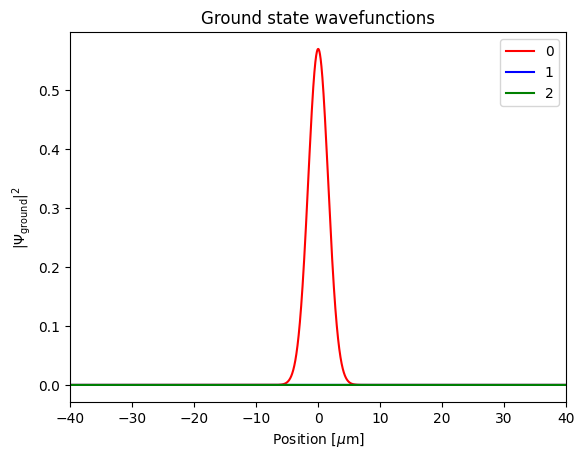

In [3]:
# Solve for the ground state

# # Guess wavefunction w/ interactions
# psi_guess = np.zeros((3, len(X)), complex)
# psi_1d_tf = np.zeros(len(X), complex)
# mu_1d = (3.0 / 2.0 * kappa[0,0])**(2.0/3.0) / 2.0

# for i in range(nx):
    
#     if(mu_1d-U[0,i] > 0.0):
        
#         psi_1d_tf[i] = ((mu_1d-U[0,i]) / kappa[0,0])**0.5
        
# psi_guess[0] = psi_1d_tf
# psi_guess[1] = 0.001*psi_1d_tf
# psi_guess[2] = 0.001*psi_1d_tf 

# Guess wavefunction w/o interactions
psi_guess = np.zeros((3, len(X)), complex)
psi_guess[0] = np.exp(-X**2)
psi_guess[1] = 0.0001*np.exp(-X**2)
psi_guess[2] = 0.0001*np.exp(-X**2)

(K, T, psi_ground, ep, energies_ground) = gpe1d(epsilon=epsilon, kappa=kappa, Omega=0.0, Omega_2=0.0, N=8000, 
                            k=0.001, X=X, U=U, psi0=psi_guess, Ntstore=10, imag_time=1, error=0.002)

# Plot the wavefunctions 
plt.plot(X * length_scale * 1e6, np.real(psi_ground[0]*np.conj(psi_ground[0])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_ground[1]*np.conj(psi_ground[1])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_ground[2]*np.conj(psi_ground[2])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi_{\text{ground}}|^2$')
plt.xlim([-40,40])
plt.title("Ground state wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

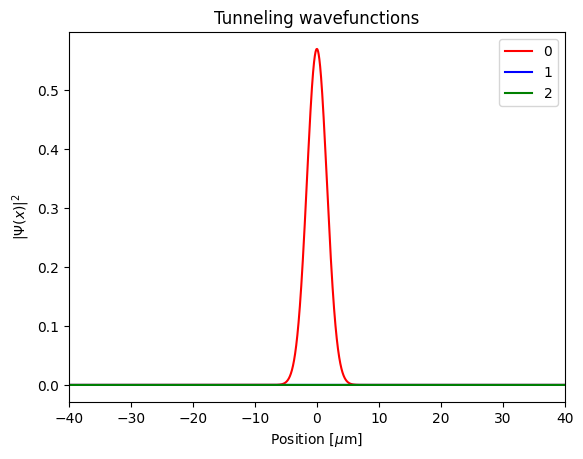

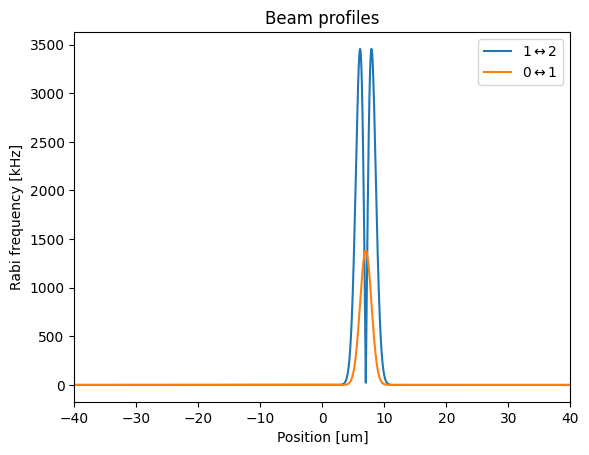

coupling minimum = 0.0 kHz


In [12]:
def TEM01(x, x0, sigma, Omega_max):
    return Omega_max**2 * 2 * ((x-x0)/sigma)**2 * np.exp(1 - 2*((x-x0)/sigma)**2)

def gaussian(x, x0, sigma, Omega_max):
    return Omega_max**2 * np.exp(-2*(x-x0)**2 / sigma**2)

# rabi drives
# Gam = 6e4 * time_scale
# Gam = hbar * (m_rb * 4e-3 / hbar)**2 * time_scale / (2 * m_rb)
coupling_max = 2*pi*550e3*time_scale
rabi_ratio = 0.4
probe_max = rabi_ratio * coupling_max
sigma = 1.3e-6

# rabi_probe = probe_max * np.exp(-((X_real-20e-6))**2 / (2*1.3e-6)**2)
# rabi_coupling = coupling_max * (np.exp(-((X_real-20e-6+2.5*1.3e-6))**2 / (1.3e-6)**2) + np.exp(-((X_real-20e-6-2.5*1.3e-6))**2 / (1.3e-6)**2))

# rabi_probe = probe_max * np.exp(-((X_real-21e-6))**2 / (1.3e-6)**2)
# rabi_coupling = coupling_max * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2)

rabi_probe = np.sqrt(gaussian(X_real, 7e-6, sigma, probe_max))
rabi_coupling= np.sqrt(TEM01(X_real, 7e-6, sigma, coupling_max))

# kick strength
k_kick = m_rb * 4e-3 * length_scale / hbar
psi_kicked = psi_ground * np.exp(1j * k_kick * X)

# hold_time = 2.5e-3 / time_scale
# dt_hold = 5e-4
# # hold_time_steps * dt_hold * time_scale = 2.5 ms

tun_time = 4e-3 / time_scale
dt_tun = 2e-4
tun_timesteps = int(tun_time / dt_tun)

U = np.zeros((3, len(X)))

# U_tun = np.zeros((3, len(X)))
# U_tun[0] = (m_rb * (5e-3)**2 / 2) * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2) / energy_scale

plt.plot(X * length_scale * 1e6, np.real(psi_kicked[0]*np.conj(psi_kicked[0])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_kicked[1]*np.conj(psi_kicked[1])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_kicked[2]*np.conj(psi_kicked[2])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.xlim([-40,40])
plt.title("Tunneling wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

plt.plot(X * length_scale * 1e6, rabi_coupling / time_scale / 1e3, label = r"$1\leftrightarrow 2$")
plt.plot(X * length_scale * 1e6, rabi_probe / time_scale / 1e3, label = r"$0\leftrightarrow 1$")
plt.title('Beam profiles')
plt.ylabel("Rabi frequency [kHz]")
plt.xlabel("Position [um]")
plt.legend()
plt.xlim([-40,40])
plt.show()

print("coupling minimum = " + str(np.min(rabi_coupling / time_scale / 1e3)) + " kHz")

(K_tun, T_tun, psi_tun, ep, energies_tun) = gpe1d(epsilon=epsilon, kappa=kappa, 
                          Omega=rabi_probe, Omega_2=rabi_coupling,
                          N=tun_timesteps, 
                          k=dt_tun, X=X, U=U, psi0=psi_kicked, Ntstore=100, 
                          imag_time=0, error=0.0002) 

state 0 population: 0.882802624353243
state 1 population: 0.05365061625397959
state 2 population: 0.06354675939480693
total population: 1.0000000000020295


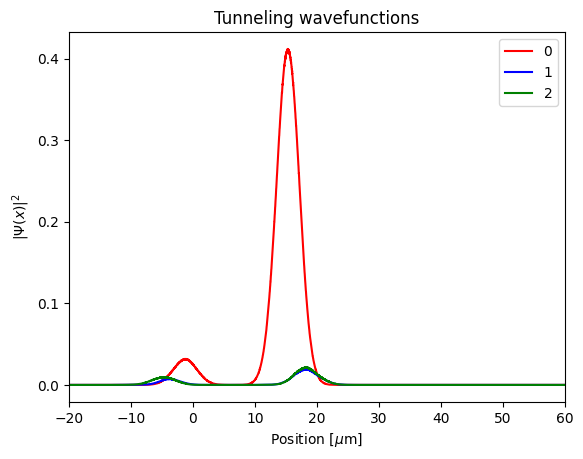

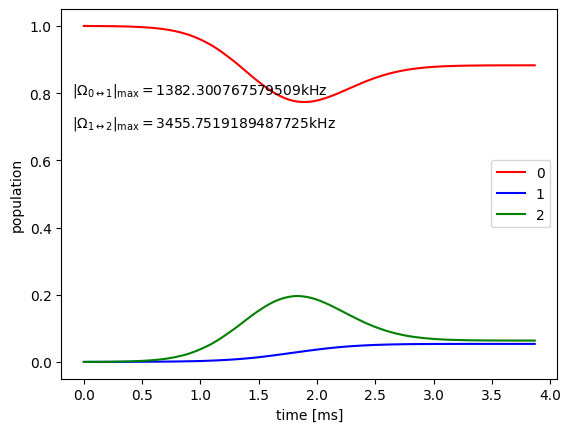

In [13]:
# Plot the wavefunctions 

index = -1

print("state 0 population: " + str(np.sum(np.real(psi_tun[0][index]*np.conj(psi_tun[0][index])))*dx))
print("state 1 population: " + str(np.sum(np.real(psi_tun[1][index]*np.conj(psi_tun[1][index])))*dx))
print("state 2 population: " + str(np.sum(np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])))*dx))
print("total population: " + str(np.sum(np.real(psi_tun[0][index]*np.conj(psi_tun[0][index])))*dx + np.sum(np.real(psi_tun[1][index]*np.conj(psi_tun[1][index])))*dx+ np.sum(np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])))*dx))

plt.plot(X * length_scale * 1e6, np.real(psi_tun[0][index]*np.conj(psi_tun[0][index])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_tun[1][index]*np.conj(psi_tun[1][index])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.xlim([-20,60])
plt.title("Tunneling wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

pops_0 = np.zeros(len(T_tun))
pops_1 = np.zeros(len(T_tun))
pops_2 = np.zeros(len(T_tun))

for i in range(len(T_tun)):
    pops_0[i] = np.sum(np.real(psi_tun[0][i]*np.conj(psi_tun[0][i])))*dx
    pops_1[i] = np.sum(np.real(psi_tun[1][i]*np.conj(psi_tun[1][i])))*dx
    pops_2[i] = np.sum(np.real(psi_tun[2][i]*np.conj(psi_tun[2][i])))*dx

plt.plot(T_tun * time_scale * 1e3, pops_0, color = 'r', label = '0')
plt.plot(T_tun * time_scale * 1e3, pops_1, color = 'b', label = '1')
plt.plot(T_tun * time_scale * 1e3, pops_2, color = 'g', label = '2')
plt.ylabel("population")
plt.xlabel("time [ms]")
plt.text(-0.1, 0.8, r"$|\Omega_{0\leftrightarrow 1}|_{\text{max}}=$" + str(probe_max / time_scale / 1e3) + "kHz")
plt.text(-0.1, 0.7, r"$|\Omega_{1\leftrightarrow 2}|_{\text{max}}=$" + str(coupling_max / time_scale / 1e3) + "kHz")
plt.legend()
plt.show()

# reflected = np.array([])
# transmitted = np.array([])

# for i in range(len(X)):
#     if X_real[i] < 20e-6:
#         reflected = np.append(reflected, np.real(psi_tun[1][-1][i] * np.conj(psi_tun[1][-1][i]))*dx)
#     else:
#         transmitted = np.append(transmitted, np.real(psi_tun[1][-1][i] * np.conj(psi_tun[1][-1][i]))*dx)

# print(np.sum(reflected), np.sum(transmitted))

52 0.14474862213438822
7.0051038686480845e-06 0.4397363013600682 3.416307971794069e-07


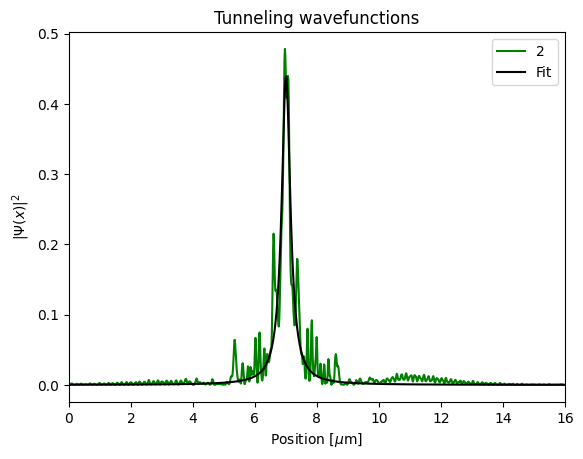

In [116]:
max_2_pop = 0
max_index = 0
for index in range(len(T_tun)):
    if np.sum(np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])))*dx > max_2_pop:
        max_2_pop = np.sum(np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])))*dx
        max_index = index

print(max_index, max_2_pop)  

def lorentzian(x, x0, A, gamma):
    return A * (gamma/2)**2 / ((x-x0)**2 + (gamma/2)**2)

x_fit = np.linspace(-2, 2, 500)
x0 = 2
Omega_ratio = 10

p0_guesses = [8e-6, np.max(np.real(psi_tun[2][max_index]*np.conj(psi_tun[2][max_index]))), 1.3e-6]
popt, pcov = curve_fit(lorentzian, X_real, np.real(psi_tun[2][max_index]*np.conj(psi_tun[2][max_index])), p0=p0_guesses, maxfev=20000)
x0_fit, A_fit, gamma_fit = popt

print(x0_fit, A_fit, gamma_fit)

plt.plot(X * length_scale * 1e6, np.real(psi_tun[2][max_index]*np.conj(psi_tun[2][max_index])), color='green', label="2")
plt.plot(X_real * 1e6, lorentzian(X_real, *popt), color = "black", label = "Fit")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.xlim([0,16])
plt.title("Tunneling wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

# Parameter Scan

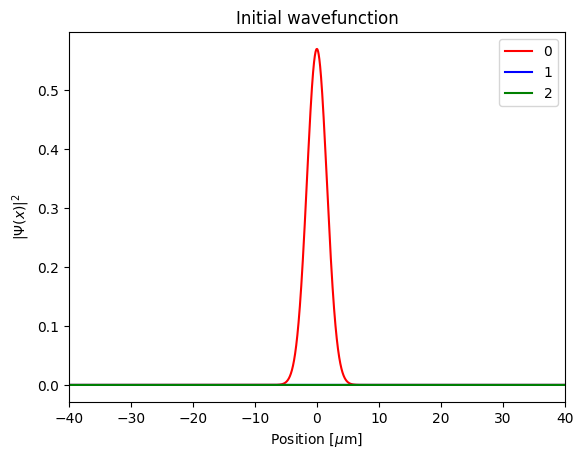

Probe max = 15.000000000000002 kHz, Coupling max = 50.000000000000014 kHz
Reflected fraction: 0.08239719377482112, Transmitted fraction: 0.9176028062272373
State 1 population: 0.28146034447137486


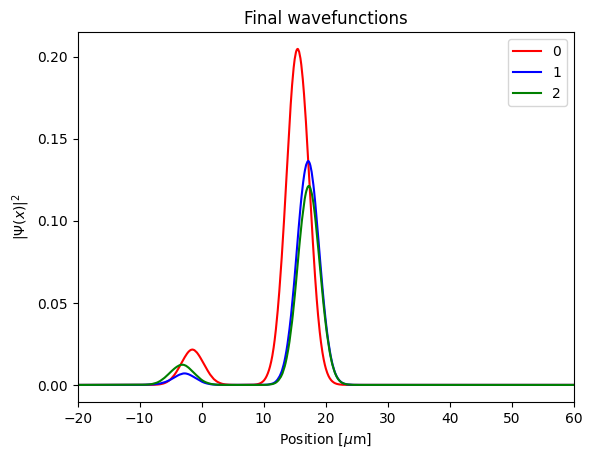

Gamma = 0.40568409714681786 um


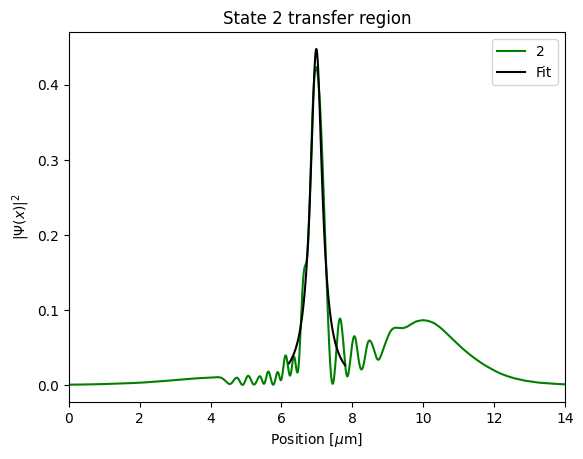

Probe max = 18.445945945945944 kHz, Coupling max = 61.4864864864865 kHz
Reflected fraction: 0.09907494330971749, Transmitted fraction: 0.9009250566923482
State 1 population: 0.299107494451759


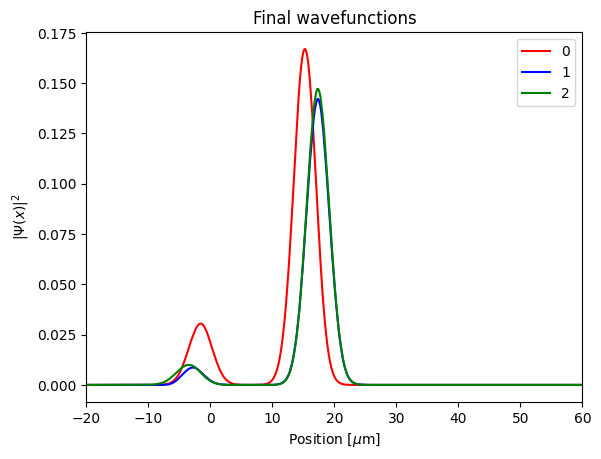

Gamma = 0.38863490976251436 um


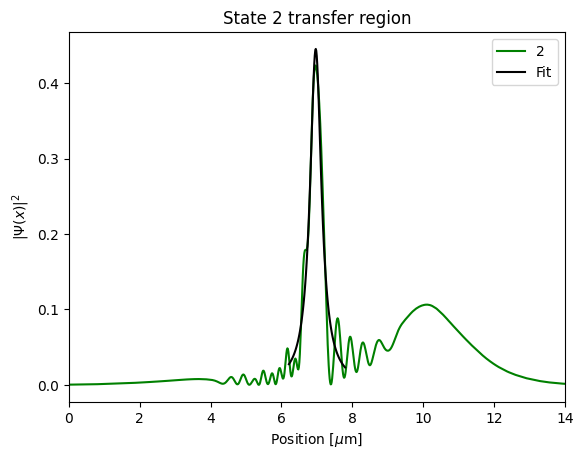

Probe max = 21.891891891891888 kHz, Coupling max = 72.97297297297298 kHz
Reflected fraction: 0.10514758250976254, Transmitted fraction: 0.8948524174923292
State 1 population: 0.2852822065060529


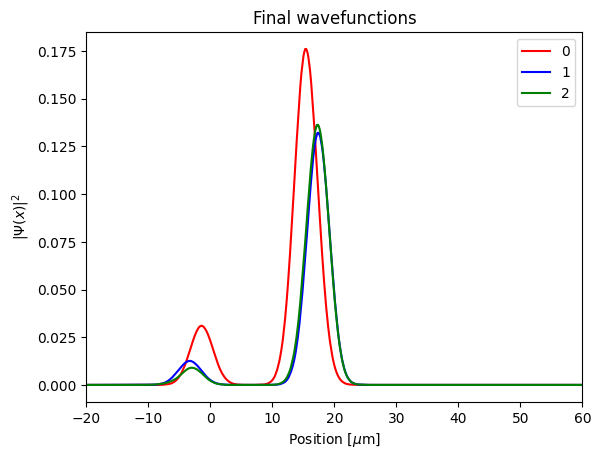

Gamma = 0.38700695386485806 um


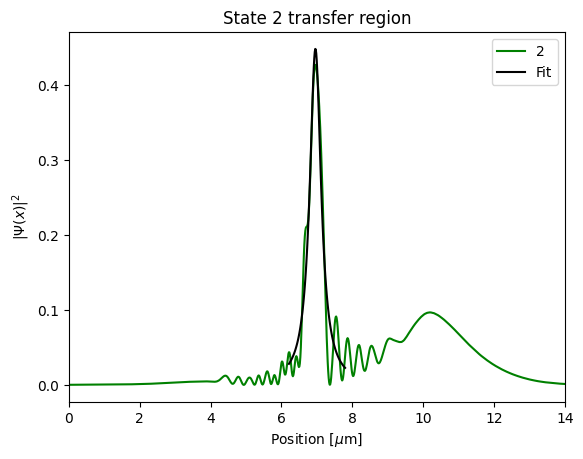

Probe max = 25.337837837837835 kHz, Coupling max = 84.45945945945945 kHz
Reflected fraction: 0.1225237067380871, Transmitted fraction: 0.8774762932640047
State 1 population: 0.2642339724073654


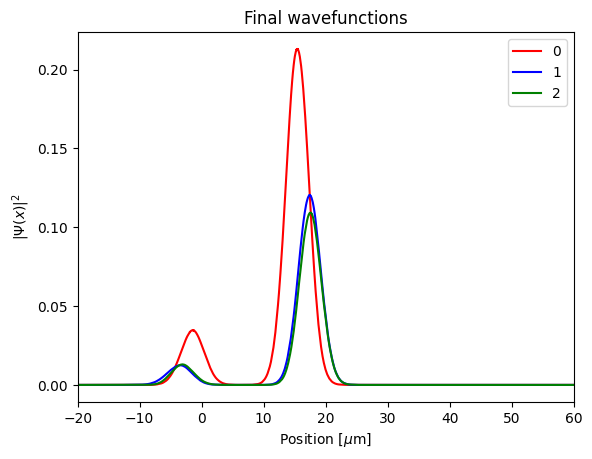

Gamma = 0.35656850702049886 um


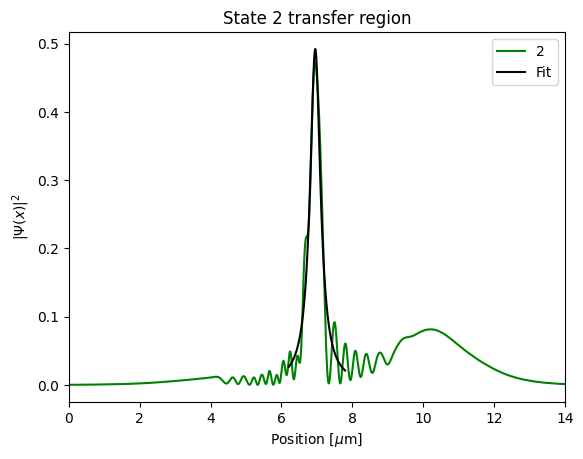

Probe max = 28.783783783783775 kHz, Coupling max = 95.94594594594594 kHz
Reflected fraction: 0.12872253215455956, Transmitted fraction: 0.8712774678475216
State 1 population: 0.2666176737569609


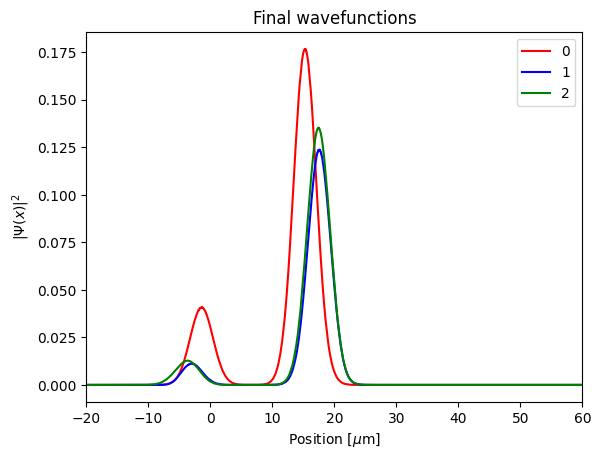

Gamma = 0.3649877570921194 um


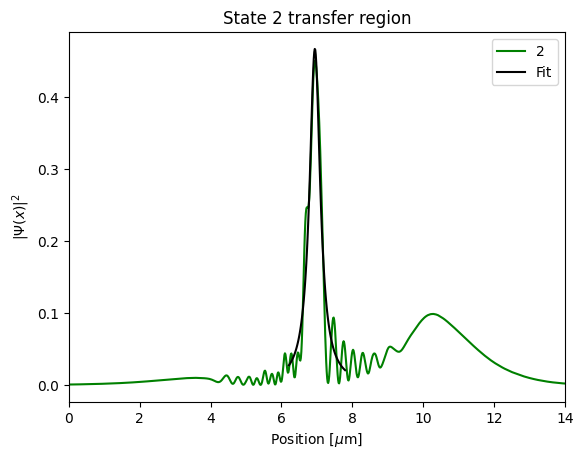

Probe max = 32.229729729729726 kHz, Coupling max = 107.43243243243244 kHz
Reflected fraction: 0.14036938497077356, Transmitted fraction: 0.8596306150313294
State 1 population: 0.24334410470975368


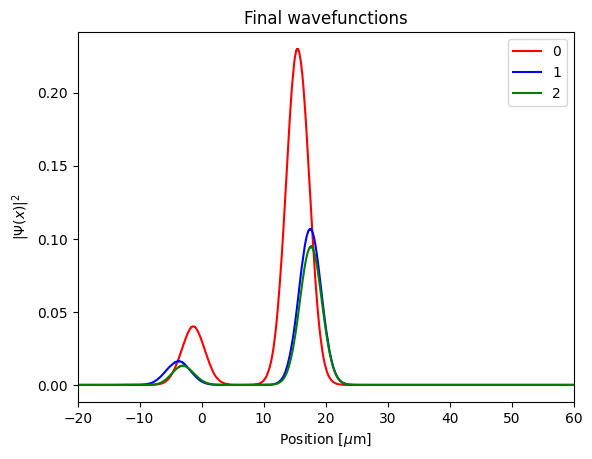

Gamma = 0.34525280919499507 um


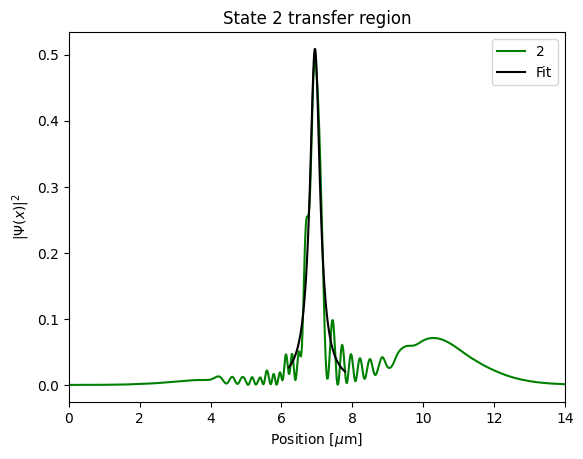

Probe max = 35.67567567567567 kHz, Coupling max = 118.91891891891892 kHz
Reflected fraction: 0.14680174991155784, Transmitted fraction: 0.8531982500905168
State 1 population: 0.24600293925954753


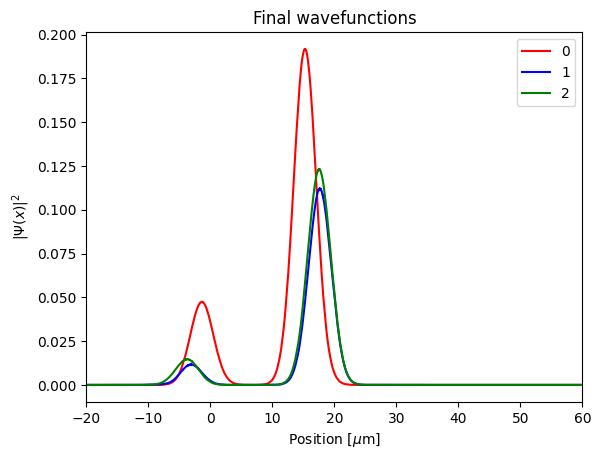

Gamma = 0.3549078124283079 um


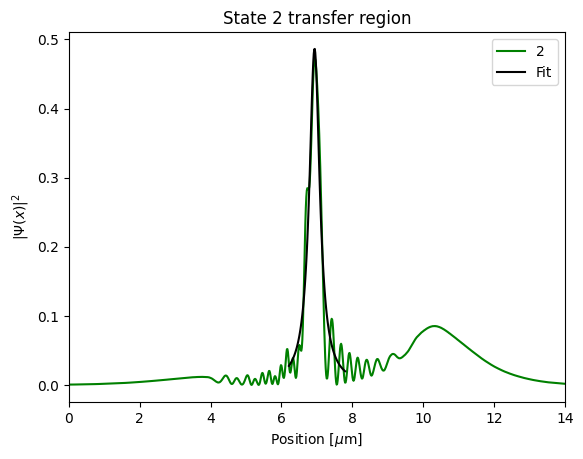

Probe max = 39.12162162162163 kHz, Coupling max = 130.40540540540545 kHz
Reflected fraction: 0.1570590281912147, Transmitted fraction: 0.8429409718108868
State 1 population: 0.22408023387515533


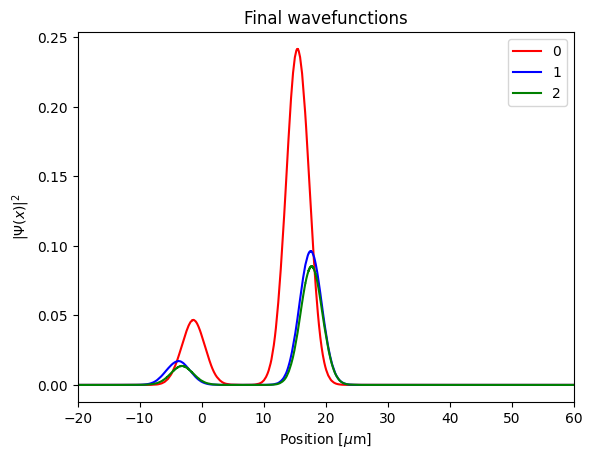

Gamma = 0.33642869263638797 um


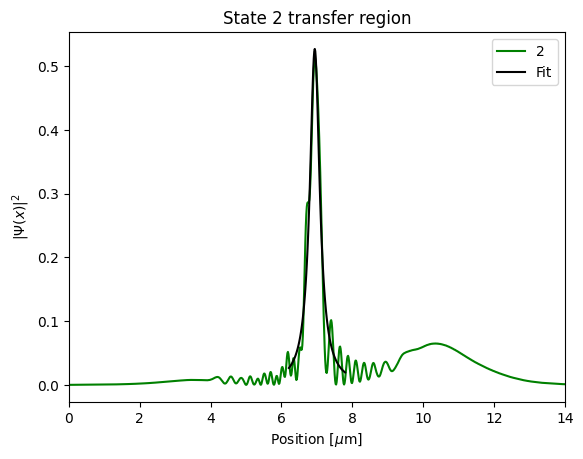

Probe max = 42.56756756756756 kHz, Coupling max = 141.89189189189185 kHz
Reflected fraction: 0.15930908458850504, Transmitted fraction: 0.8406909154135912
State 1 population: 0.22570766411398552


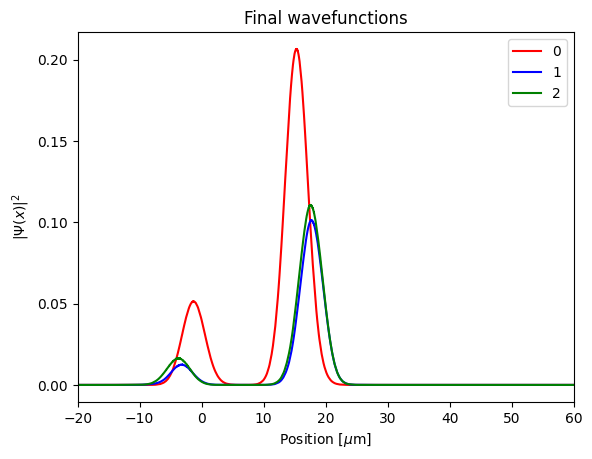

Gamma = 0.3457434307679125 um


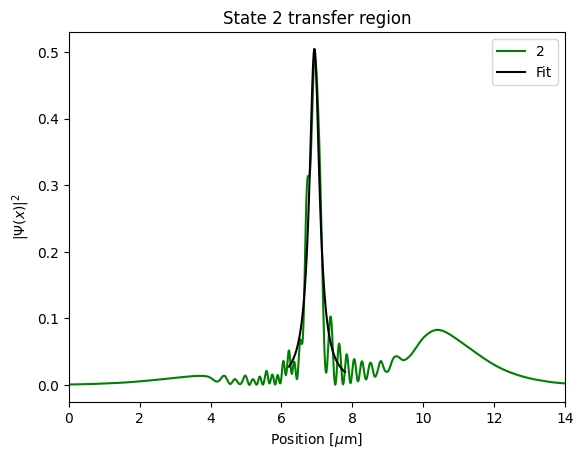

Probe max = 46.01351351351352 kHz, Coupling max = 153.3783783783784 kHz
Reflected fraction: 0.17267624284519092, Transmitted fraction: 0.8273237571568982
State 1 population: 0.21197125558582894


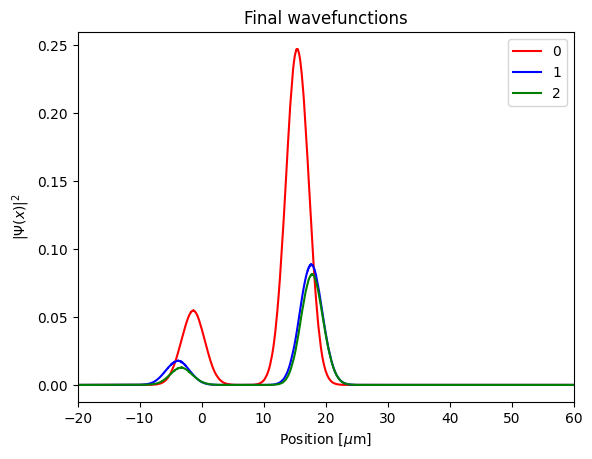

Gamma = 0.3357248661336989 um


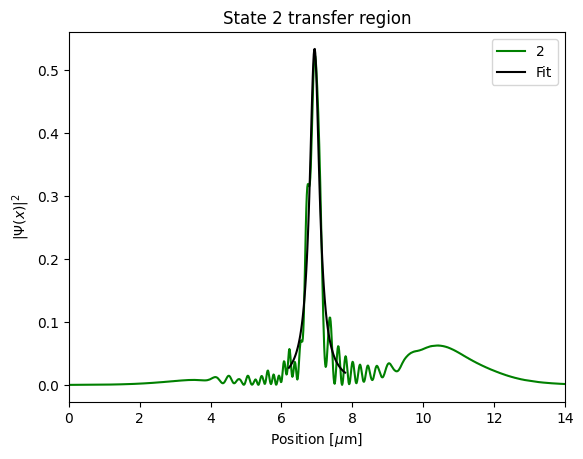

Probe max = 49.459459459459445 kHz, Coupling max = 164.86486486486484 kHz
Reflected fraction: 0.16903308996848154, Transmitted fraction: 0.8309669100336271
State 1 population: 0.20131779785590354


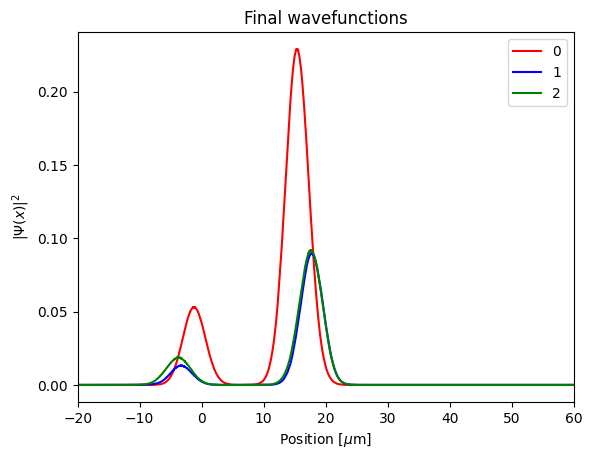

Gamma = 0.3401041527483478 um


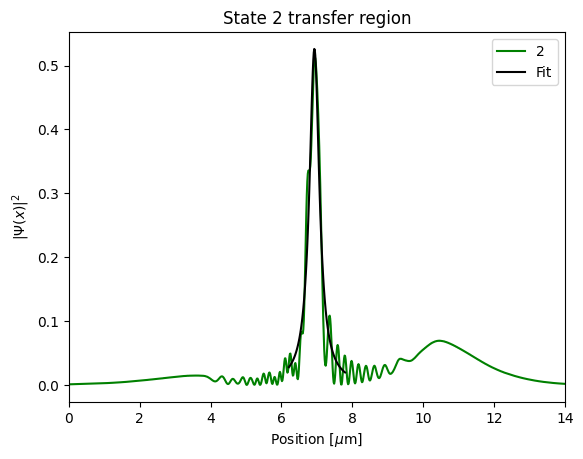

Probe max = 52.90540540540541 kHz, Coupling max = 176.35135135135138 kHz
Reflected fraction: 0.1840533276930556, Transmitted fraction: 0.8159466723090215
State 1 population: 0.20780740863135821


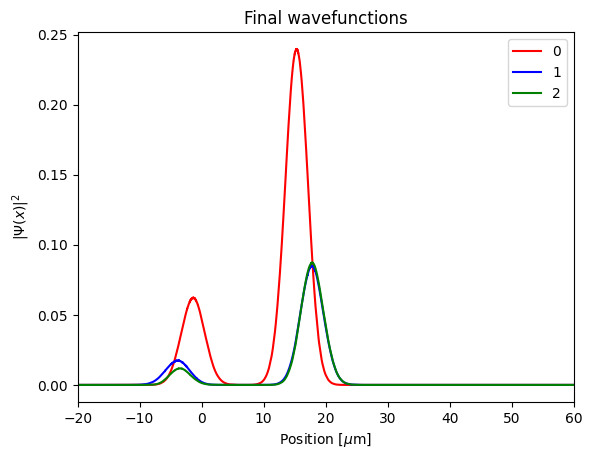

Gamma = 0.3362028512297359 um


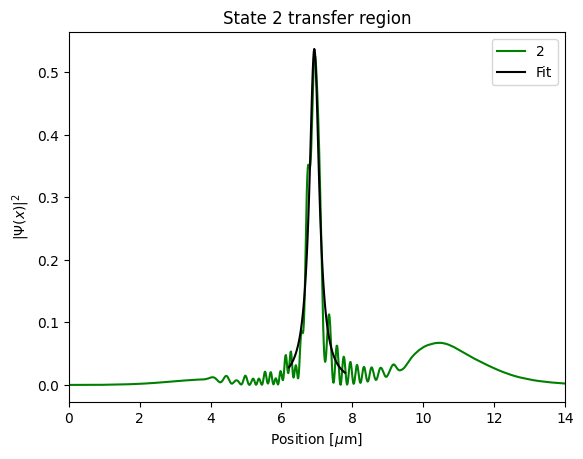

Probe max = 56.35135135135135 kHz, Coupling max = 187.8378378378378 kHz
Reflected fraction: 0.18164075853126543, Transmitted fraction: 0.8183592414708459
State 1 population: 0.17777132748775912


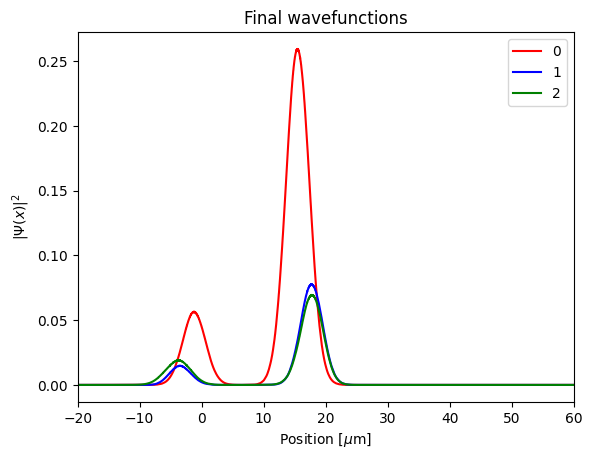

Gamma = 0.33334221988476437 um


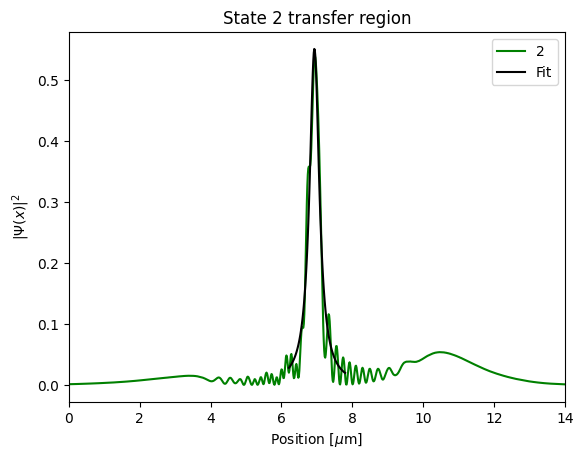

Probe max = 59.7972972972973 kHz, Coupling max = 199.32432432432435 kHz
Reflected fraction: 0.18758978891171002, Transmitted fraction: 0.8124102110904069
State 1 population: 0.19814818357793532


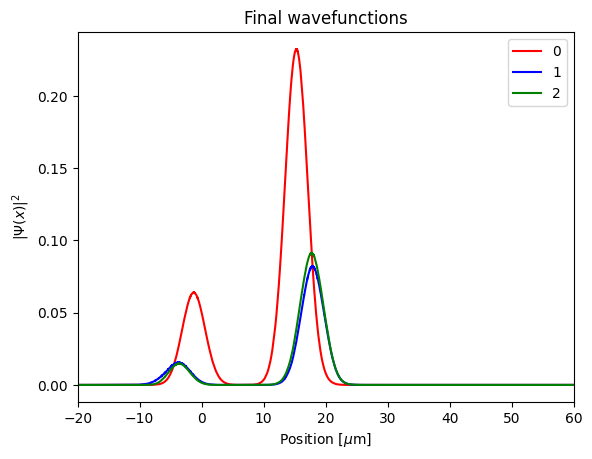

Gamma = 0.3359411413527554 um


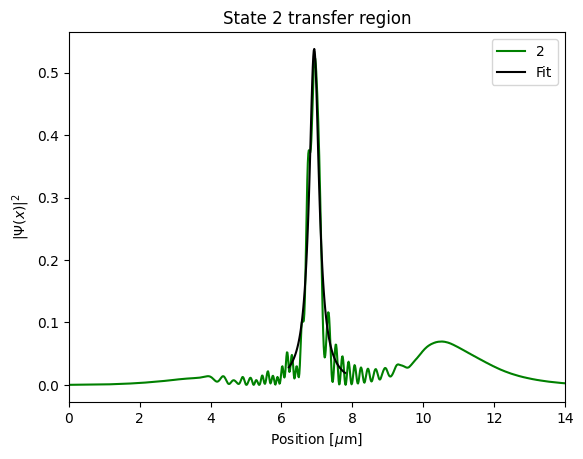

Probe max = 63.24324324324323 kHz, Coupling max = 210.81081081081078 kHz
Reflected fraction: 0.19695024731615876, Transmitted fraction: 0.8030497526859105
State 1 population: 0.17425828611279354


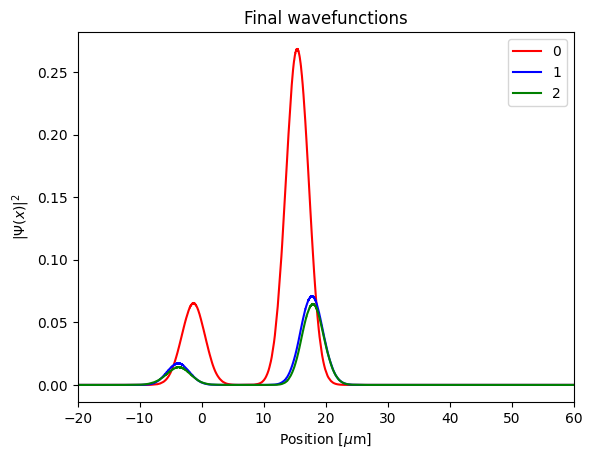

Gamma = 0.33251981578411527 um


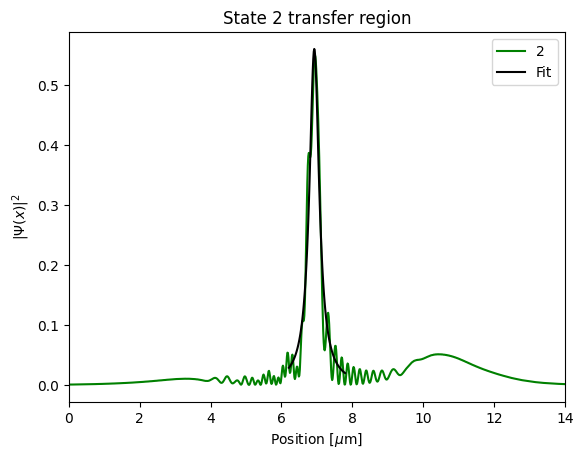

Probe max = 66.68918918918918 kHz, Coupling max = 222.2972972972973 kHz
Reflected fraction: 0.19114479725271985, Transmitted fraction: 0.8088552027494023
State 1 population: 0.16921156420071023


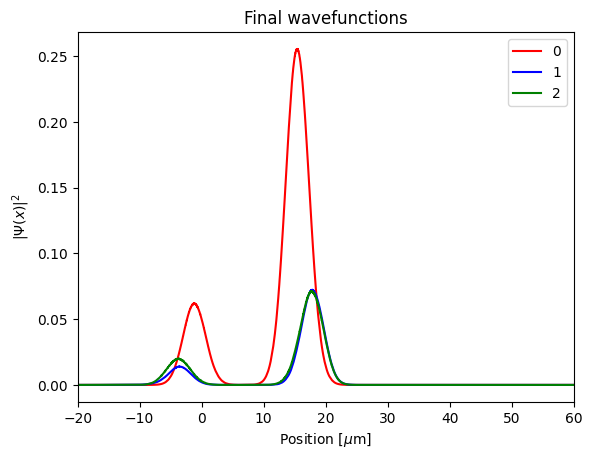

Gamma = 0.33260000759221253 um


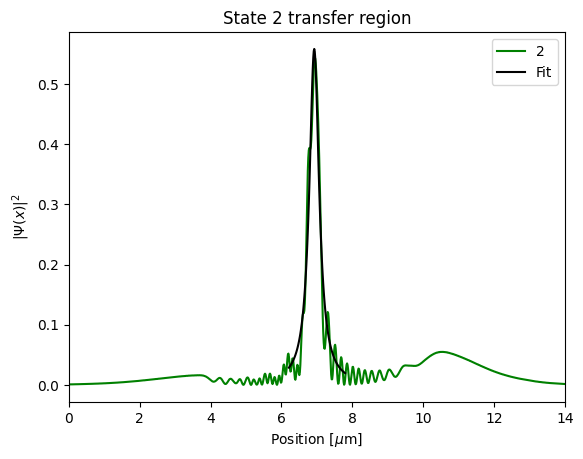

Probe max = 70.13513513513513 kHz, Coupling max = 233.78378378378375 kHz
Reflected fraction: 0.20225974510460668, Transmitted fraction: 0.7977402548975238
State 1 population: 0.1833341721604899


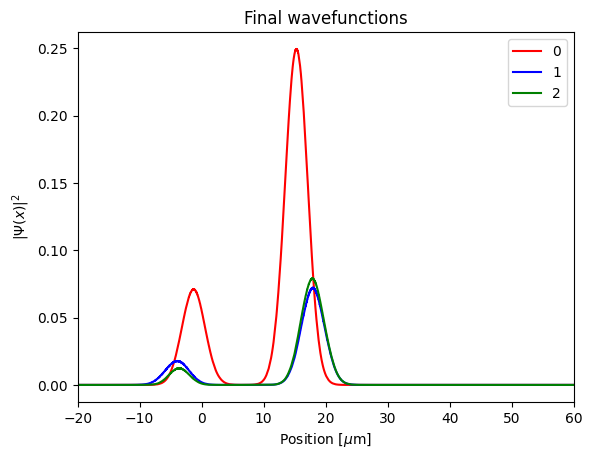

Gamma = 0.33293297510147996 um


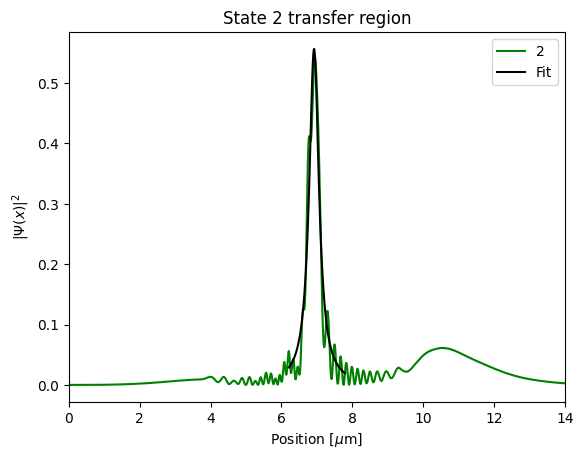

Probe max = 73.58108108108108 kHz, Coupling max = 245.2702702702703 kHz
Reflected fraction: 0.2054196616404655, Transmitted fraction: 0.7945803383616181
State 1 population: 0.1515715045701992


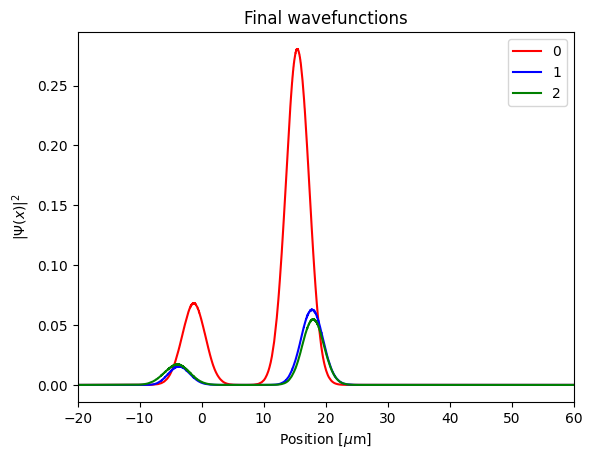

Gamma = 0.3300472822041196 um


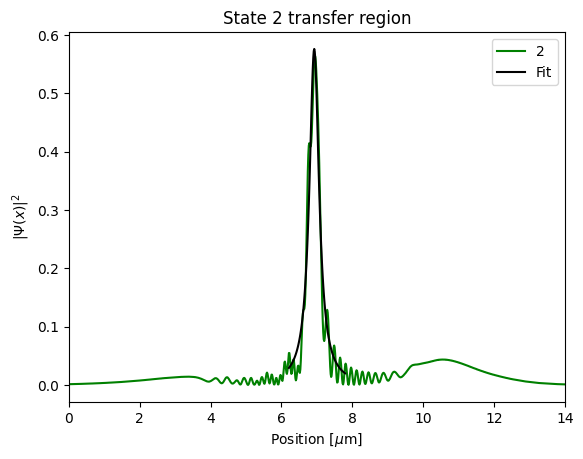

Probe max = 77.02702702702703 kHz, Coupling max = 256.7567567567568 kHz
Reflected fraction: 0.200746177785682, Transmitted fraction: 0.7992538222164521
State 1 population: 0.16265937071667672


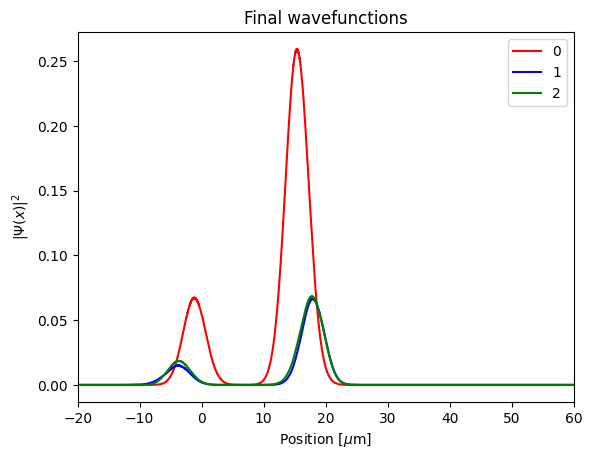

Gamma = 0.33075147663710863 um


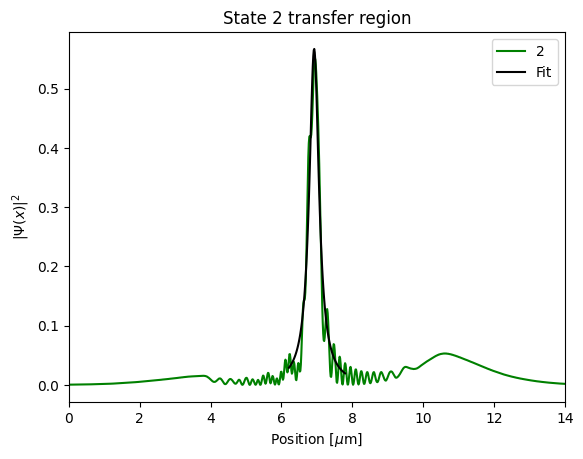

Probe max = 80.47297297297297 kHz, Coupling max = 268.24324324324317 kHz
Reflected fraction: 0.212109014615864, Transmitted fraction: 0.7878909853862895
State 1 population: 0.16760574132694453


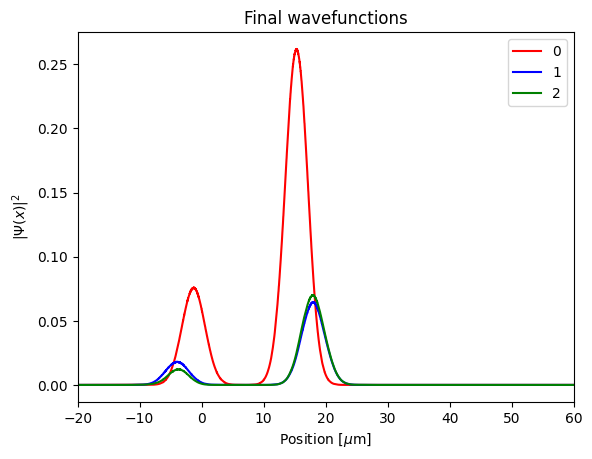

Gamma = 0.3314486381108262 um


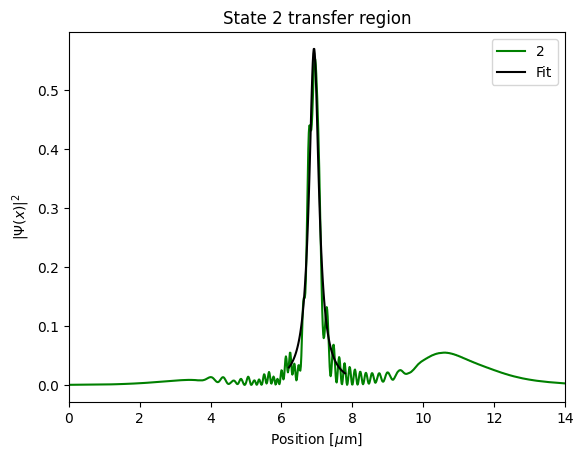

Probe max = 83.9189189189189 kHz, Coupling max = 279.7297297297297 kHz
Reflected fraction: 0.21346397687854418, Transmitted fraction: 0.786536023123595
State 1 population: 0.13815914252987896


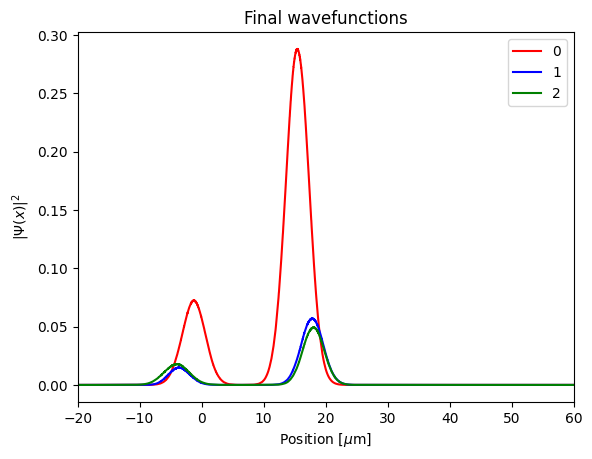

Gamma = 0.3277424912704048 um


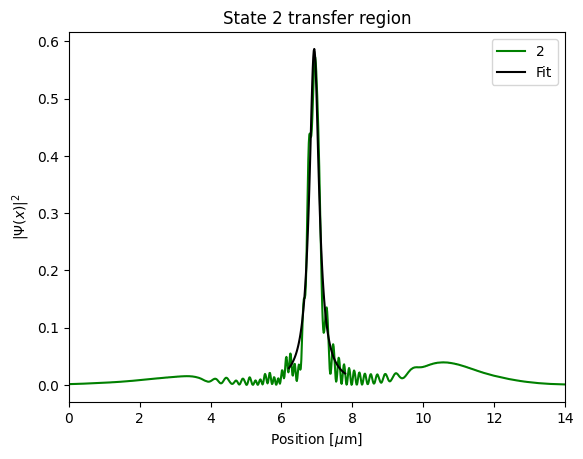

Probe max = 87.36486486486486 kHz, Coupling max = 291.2162162162162 kHz
Reflected fraction: 0.208507714939495, Transmitted fraction: 0.7914922850626293
State 1 population: 0.15216127313502523


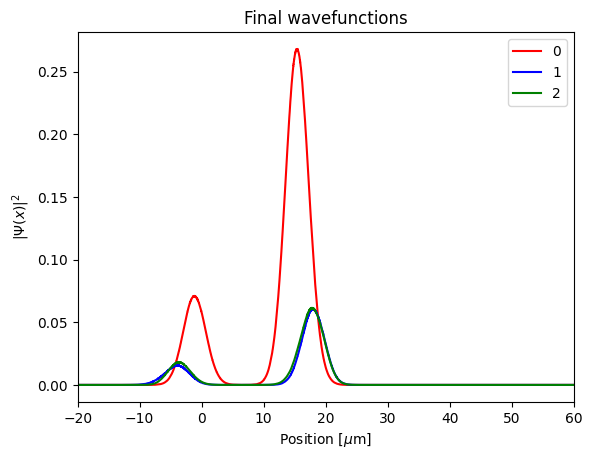

Gamma = 0.32731539190143405 um


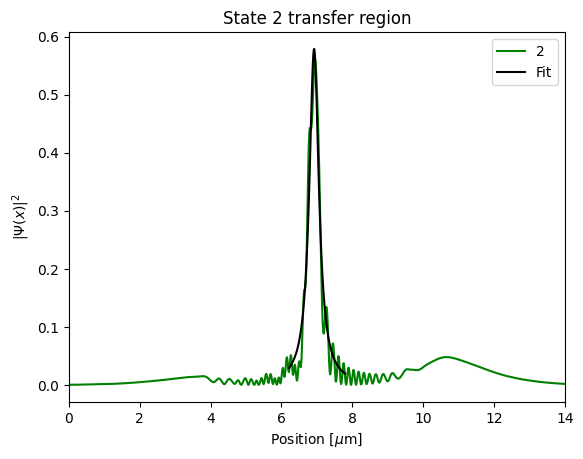

Probe max = 90.81081081081079 kHz, Coupling max = 302.7027027027027 kHz
Reflected fraction: 0.2185311771349913, Transmitted fraction: 0.7814688228671193
State 1 population: 0.1568072682304103


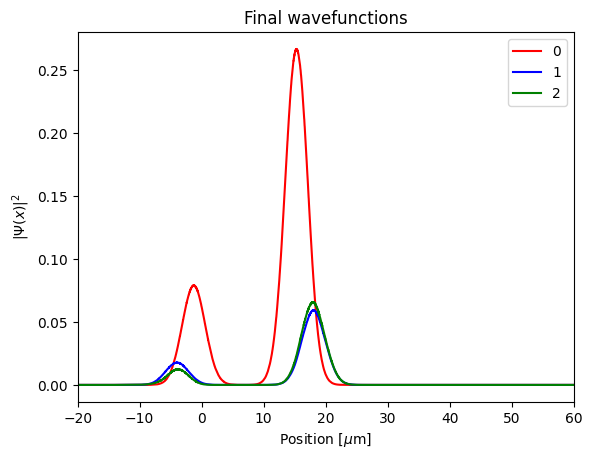

Gamma = 0.3293375629008348 um


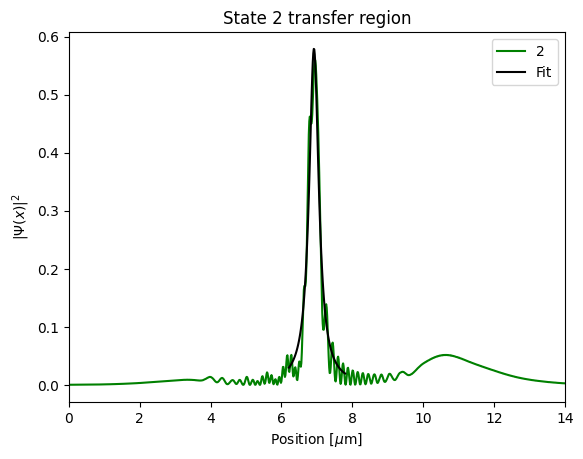

Probe max = 94.25675675675673 kHz, Coupling max = 314.1891891891891 kHz
Reflected fraction: 0.2216050974677637, Transmitted fraction: 0.7783949025343595
State 1 population: 0.12935877325703404


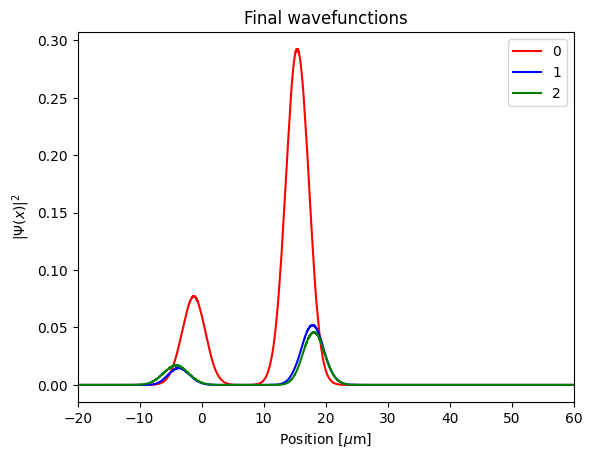

Gamma = 0.32592443628004375 um


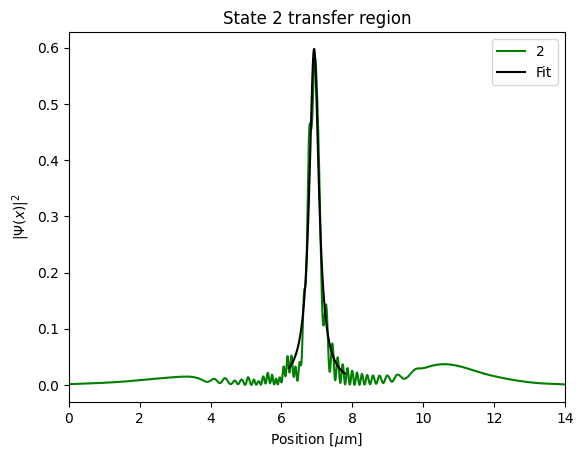

Probe max = 97.70270270270271 kHz, Coupling max = 325.6756756756757 kHz
Reflected fraction: 0.2151685966793755, Transmitted fraction: 0.7848314033227471
State 1 population: 0.1384228056011075


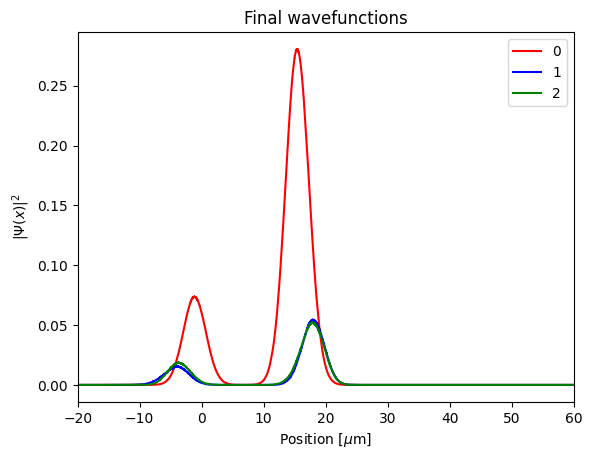

Gamma = 0.3258748849080147 um


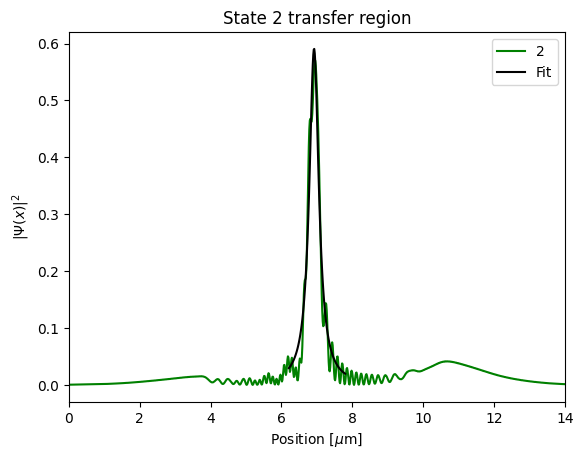

Probe max = 101.14864864864866 kHz, Coupling max = 337.16216216216213 kHz
Reflected fraction: 0.22189892202442452, Transmitted fraction: 0.7781010779777058
State 1 population: 0.1493581125040534


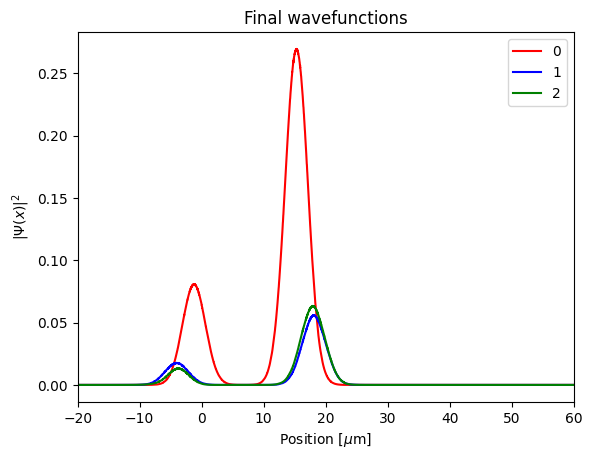

Gamma = 0.32572977582294704 um


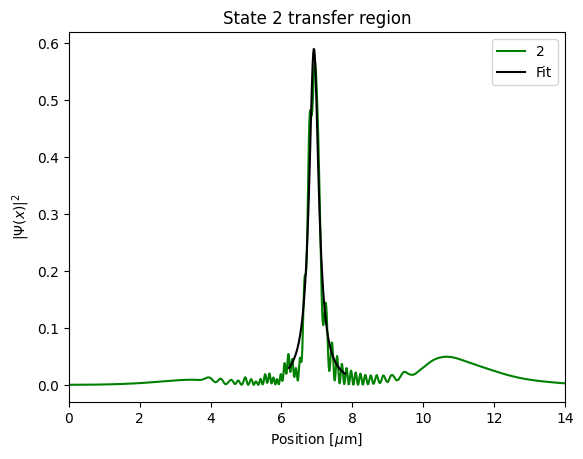

Probe max = 104.59459459459458 kHz, Coupling max = 348.64864864864865 kHz
Reflected fraction: 0.22886793182615642, Transmitted fraction: 0.7711320681759836
State 1 population: 0.1258039588992201


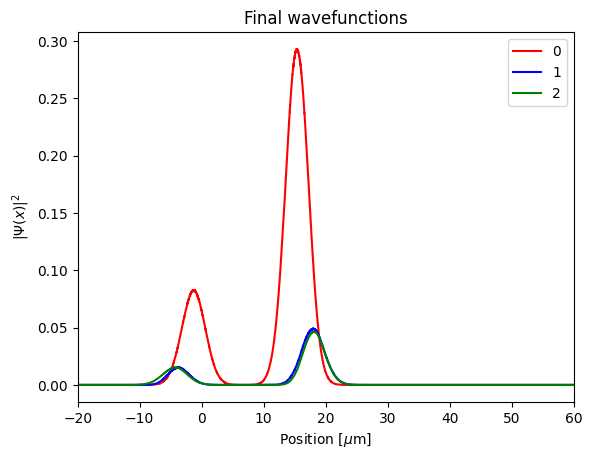

Gamma = 0.32421002355283096 um


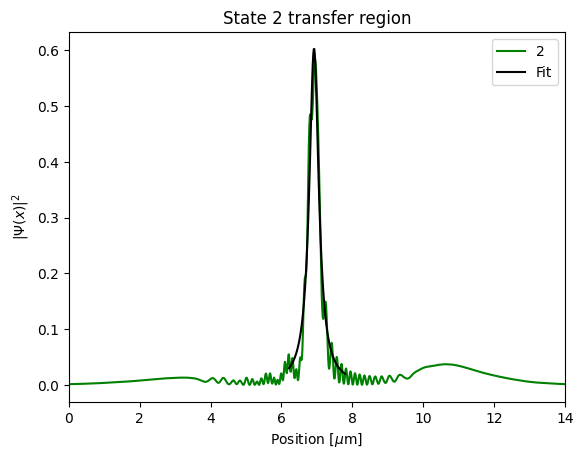

Probe max = 108.04054054054052 kHz, Coupling max = 360.13513513513504 kHz
Reflected fraction: 0.22275085522689317, Transmitted fraction: 0.7772491447752575
State 1 population: 0.12297910860298177


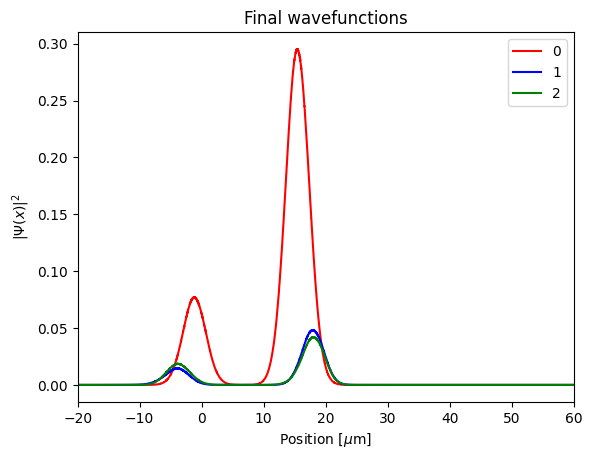

Gamma = 0.3237538881393873 um


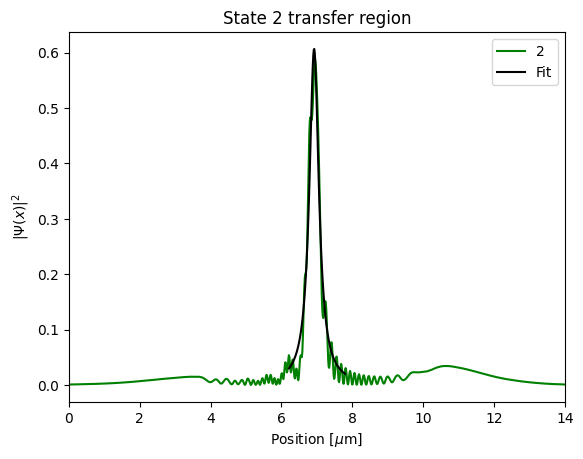

Probe max = 111.48648648648647 kHz, Coupling max = 371.6216216216216 kHz
Reflected fraction: 0.2231972248544998, Transmitted fraction: 0.7768027751476272
State 1 population: 0.1401908379858062


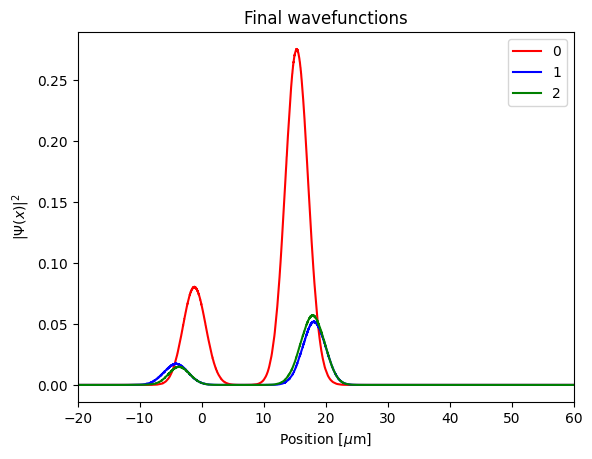

Gamma = 0.32425324619373724 um


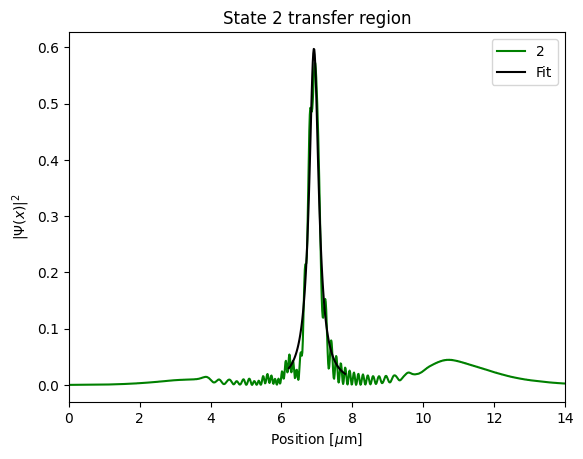

Probe max = 114.93243243243242 kHz, Coupling max = 383.1081081081081 kHz
Reflected fraction: 0.23266711740396817, Transmitted fraction: 0.7673328825981416
State 1 population: 0.12819781800305732


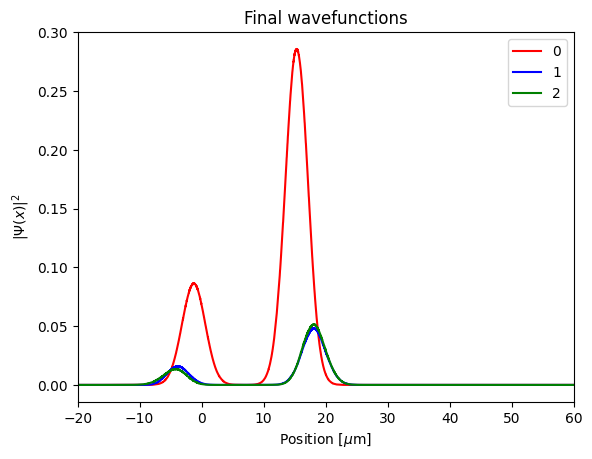

Gamma = 0.32367859341129324 um


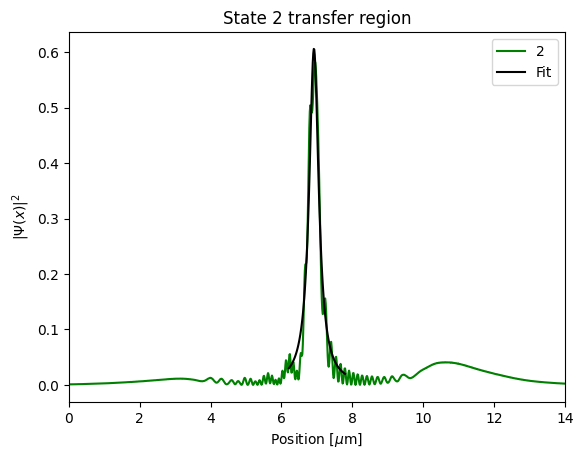

Probe max = 118.37837837837839 kHz, Coupling max = 394.5945945945946 kHz
Reflected fraction: 0.2319513714299526, Transmitted fraction: 0.7680486285721809
State 1 population: 0.11144184028552684


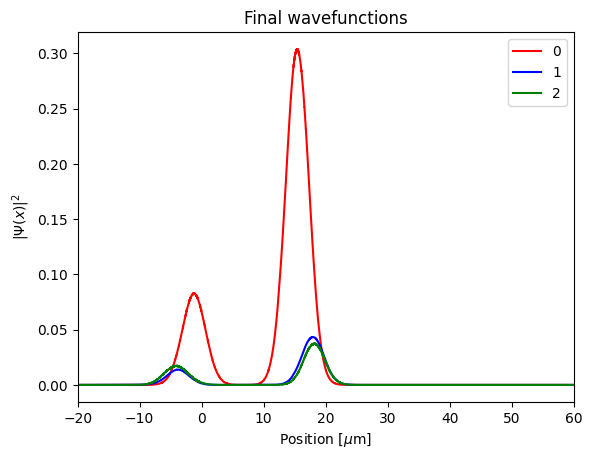

Gamma = 0.3227199613166523 um


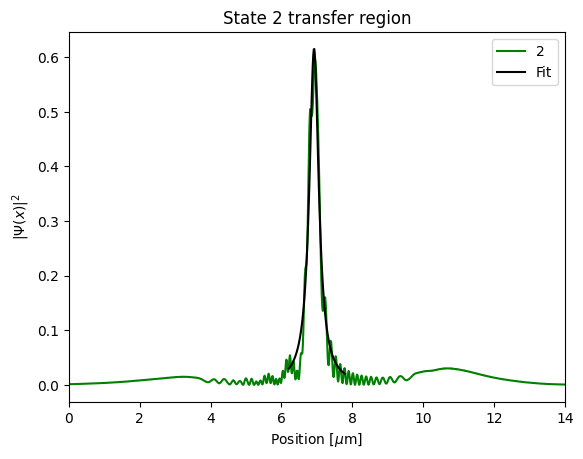

Probe max = 121.8243243243243 kHz, Coupling max = 406.081081081081 kHz
Reflected fraction: 0.22609449379426014, Transmitted fraction: 0.773905506207847
State 1 population: 0.12475414952729368


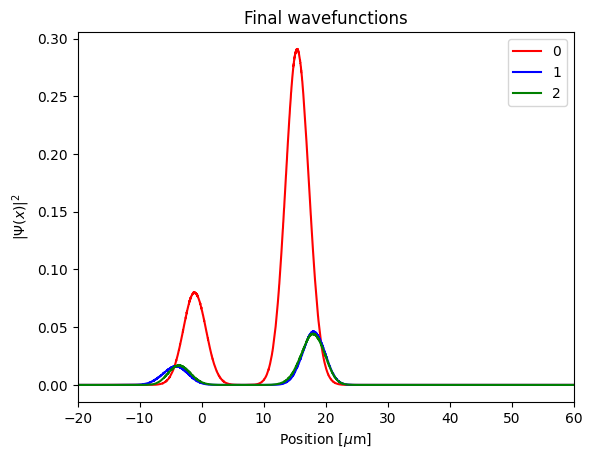

Gamma = 0.32186822970995244 um


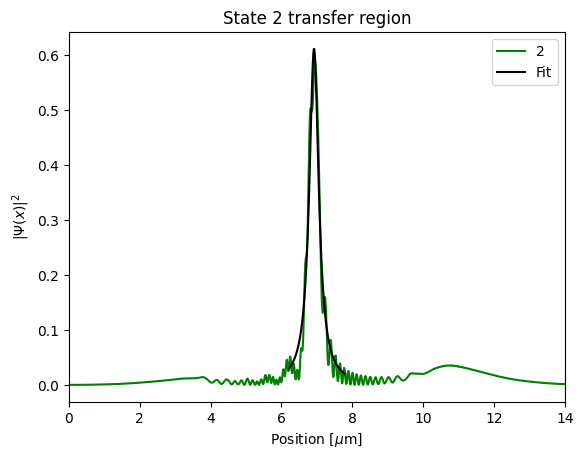

Probe max = 125.27027027027023 kHz, Coupling max = 417.5675675675675 kHz
Reflected fraction: 0.23155834934486758, Transmitted fraction: 0.7684416506572718
State 1 population: 0.13010854165295213


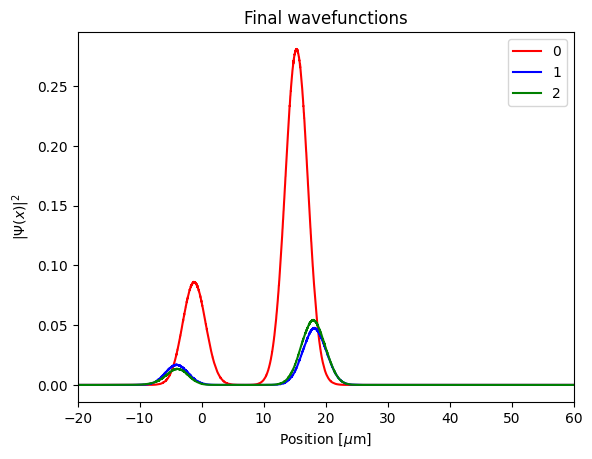

Gamma = 0.3218435672374221 um


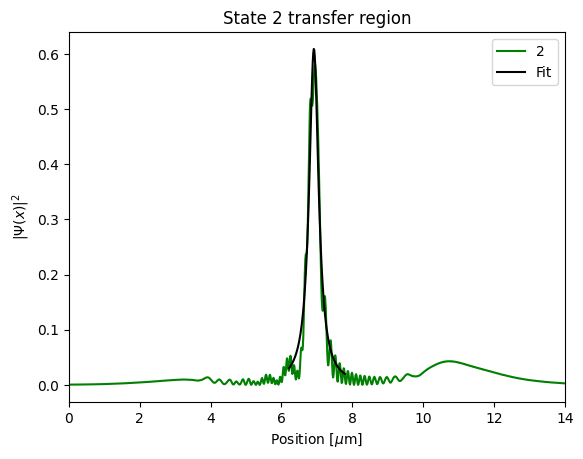

Probe max = 128.7162162162162 kHz, Coupling max = 429.05405405405406 kHz
Reflected fraction: 0.23860651357907794, Transmitted fraction: 0.7613934864230579
State 1 population: 0.11183203769203351


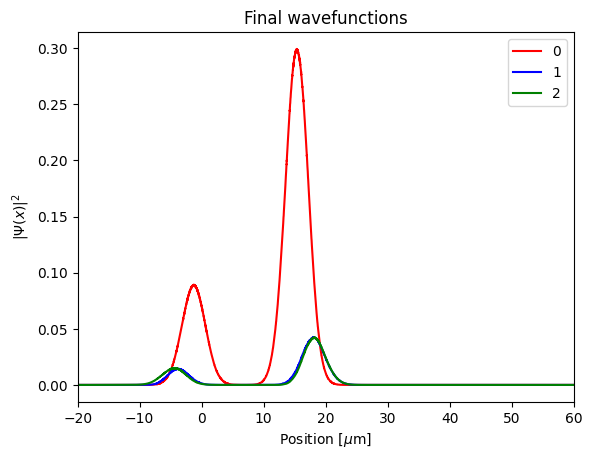

Gamma = 0.3208668478352385 um


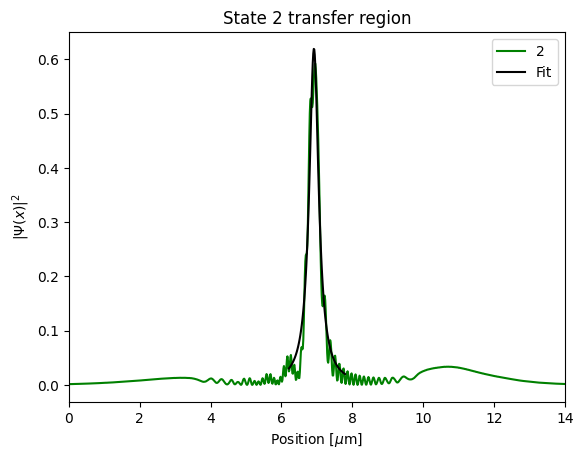

Probe max = 132.16216216216213 kHz, Coupling max = 440.54054054054046 kHz
Reflected fraction: 0.23424186680504844, Transmitted fraction: 0.765758133197088
State 1 population: 0.10716573745750368


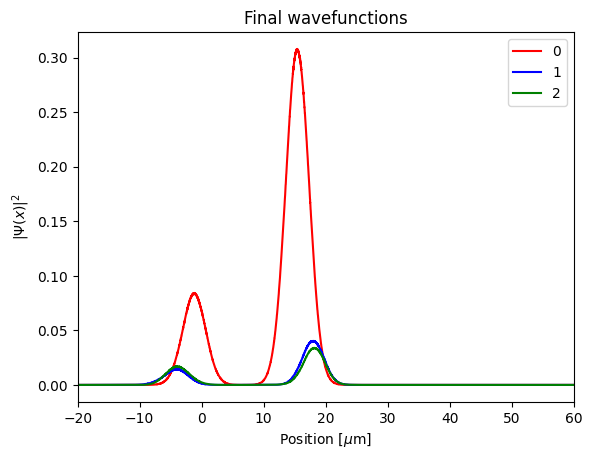

Gamma = 0.3202220568345429 um


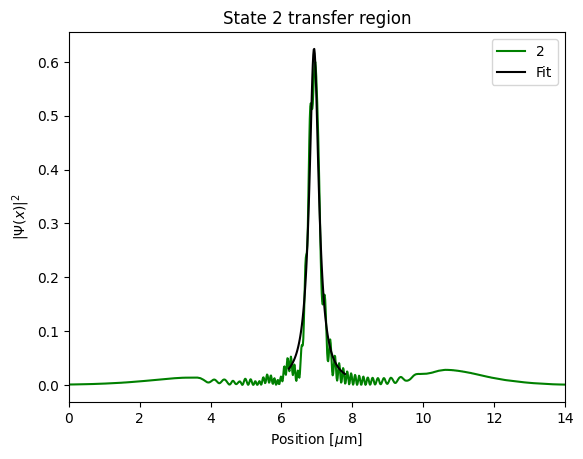

Probe max = 135.6081081081081 kHz, Coupling max = 452.02702702702703 kHz
Reflected fraction: 0.230546060081738, Transmitted fraction: 0.7694539399203972
State 1 population: 0.12115367933389778


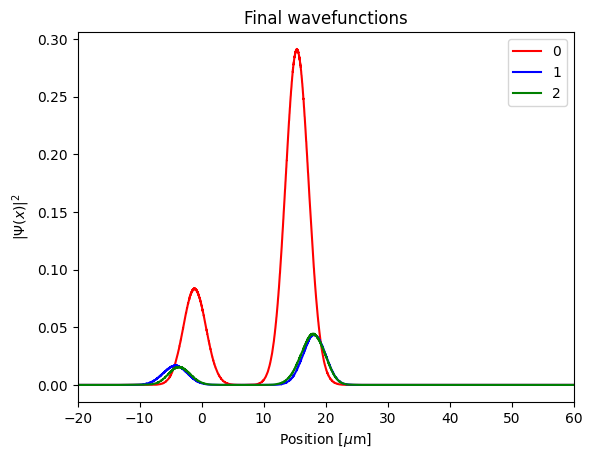

Gamma = 0.3192596097149676 um


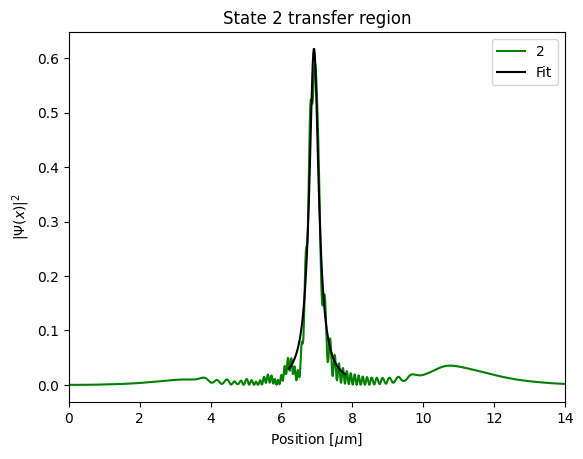

Probe max = 139.05405405405403 kHz, Coupling max = 463.51351351351343 kHz
Reflected fraction: 0.2373528518281673, Transmitted fraction: 0.7626471481739607
State 1 population: 0.11915863480228238


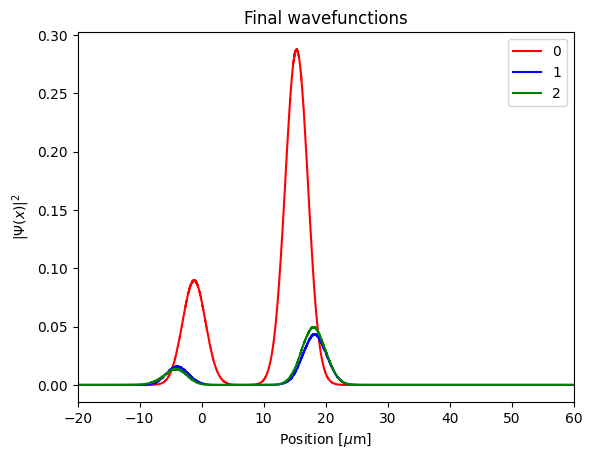

Gamma = 0.31986177938858984 um


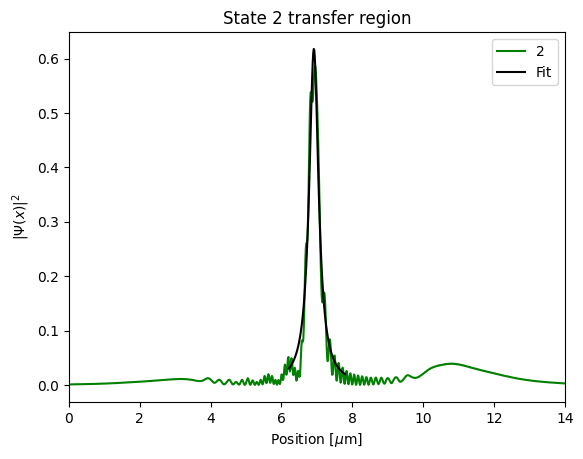

Probe max = 142.5 kHz, Coupling max = 475.0000000000001 kHz
Reflected fraction: 0.24246161674616515, Transmitted fraction: 0.7575383832559724
State 1 population: 0.1028014448348075


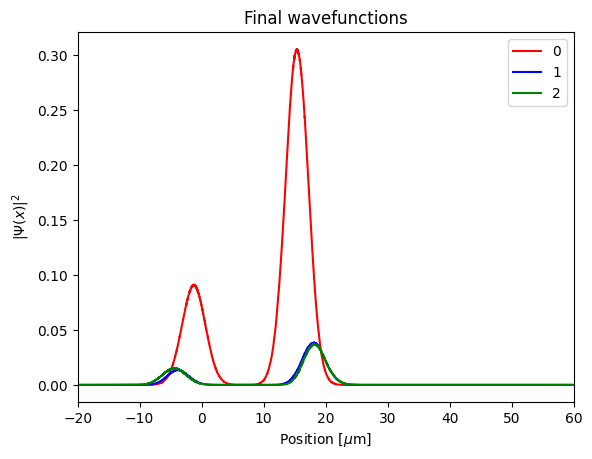

Gamma = 0.3189772715879737 um


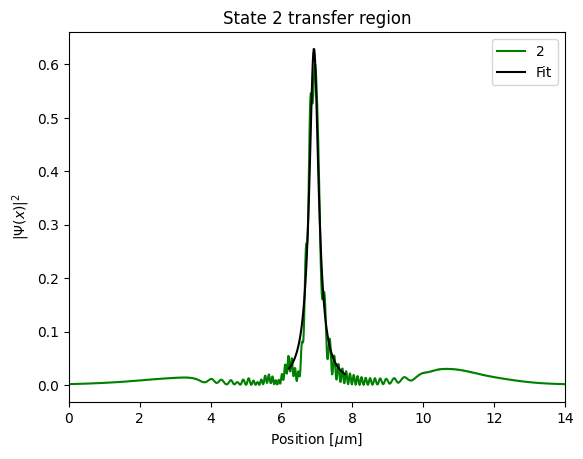

Probe max = 145.94594594594597 kHz, Coupling max = 486.48648648648657 kHz
Reflected fraction: 0.23728419003732715, Transmitted fraction: 0.7627158099647986
State 1 population: 0.10315901422427104


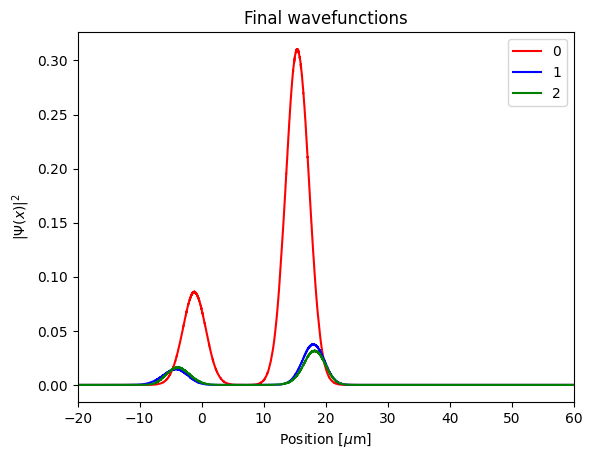

Gamma = 0.3182761878276964 um


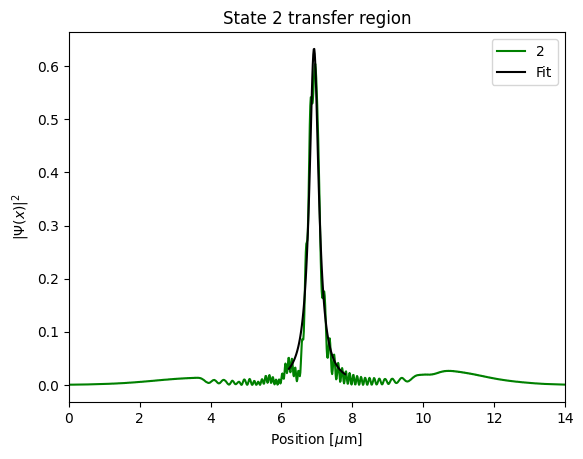

Probe max = 149.39189189189187 kHz, Coupling max = 497.97297297297297 kHz
Reflected fraction: 0.23427527285641275, Transmitted fraction: 0.7657247271457304
State 1 population: 0.11468240807777963


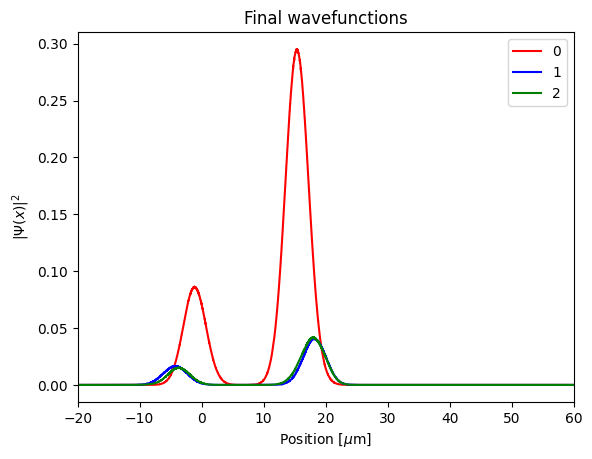

Gamma = 0.31805518572033437 um


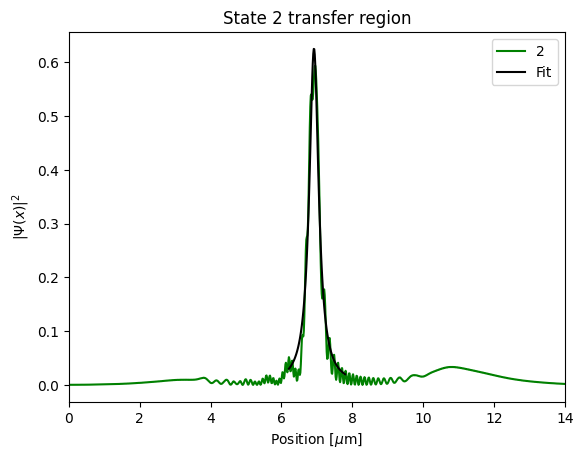

Probe max = 152.83783783783784 kHz, Coupling max = 509.4594594594594 kHz
Reflected fraction: 0.2407219071977423, Transmitted fraction: 0.7592780928043968
State 1 population: 0.11132547577717246


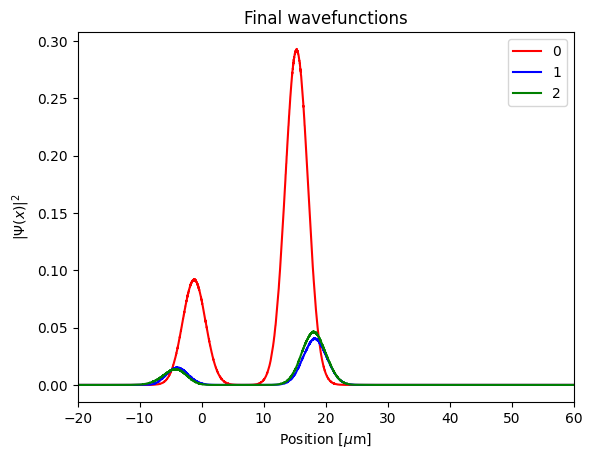

Gamma = 0.3176169675198871 um


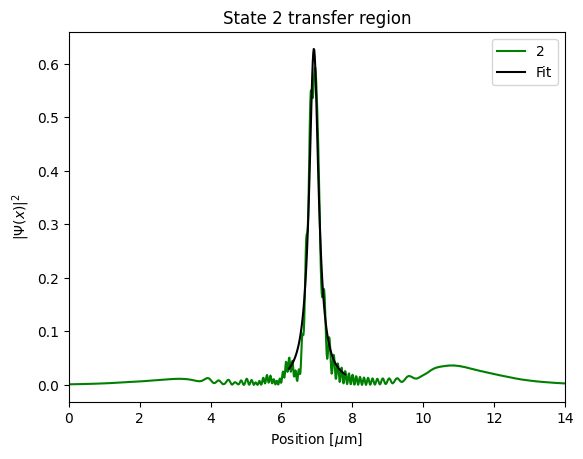

Probe max = 156.28378378378378 kHz, Coupling max = 520.9459459459459 kHz
Reflected fraction: 0.24565759103868437, Transmitted fraction: 0.7543424089634435
State 1 population: 0.0976300947996547


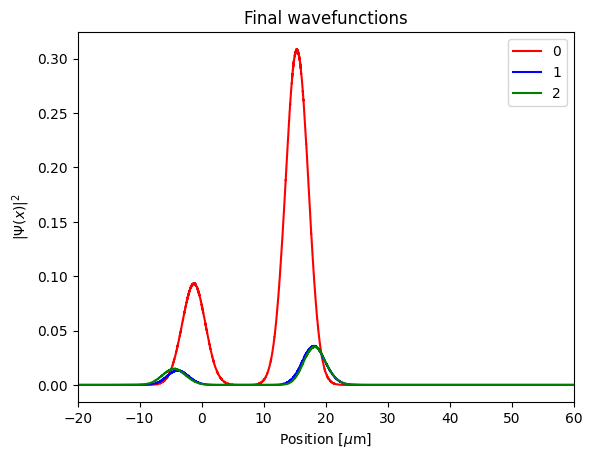

Gamma = 0.31742703161547076 um


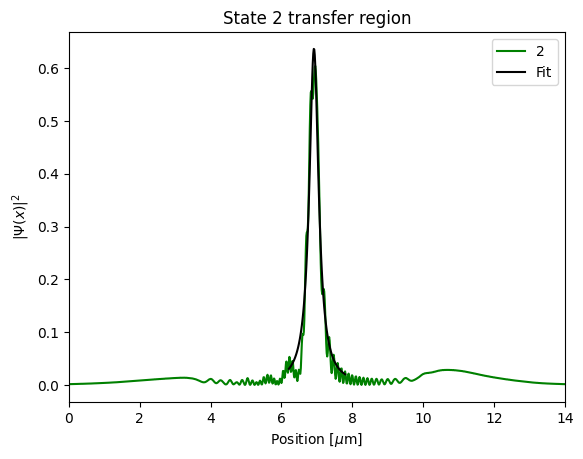

Probe max = 159.7297297297297 kHz, Coupling max = 532.4324324324324 kHz
Reflected fraction: 0.2410383540020478, Transmitted fraction: 0.7589616460001114
State 1 population: 0.09767955636562446


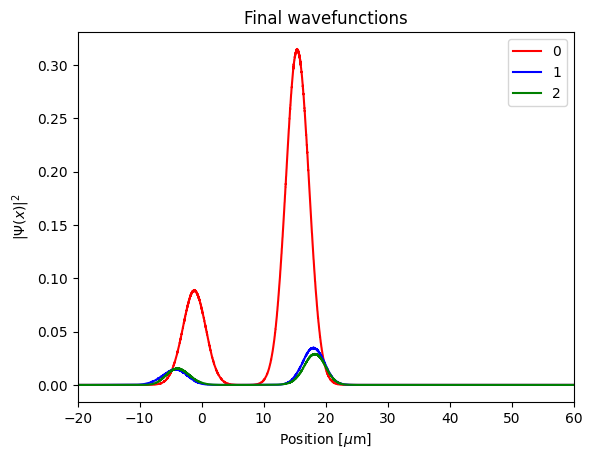

Gamma = 0.3167070001176694 um


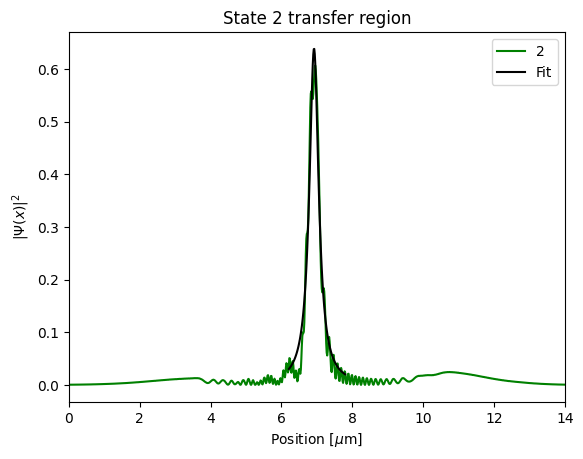

Probe max = 163.1756756756757 kHz, Coupling max = 543.9189189189191 kHz
Reflected fraction: 0.23713015595883674, Transmitted fraction: 0.7628698440432957
State 1 population: 0.10740654572871607


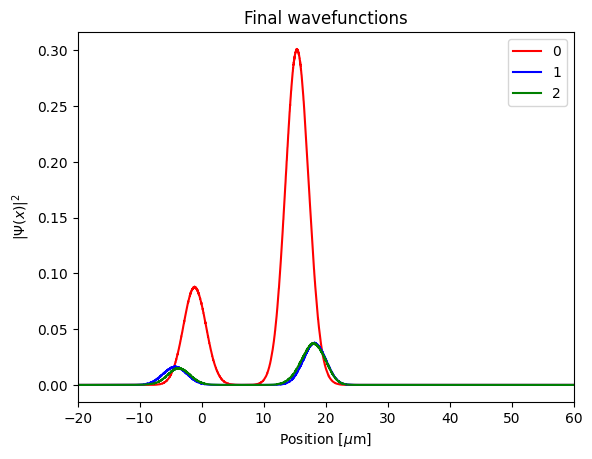

Gamma = 0.31636077789904155 um


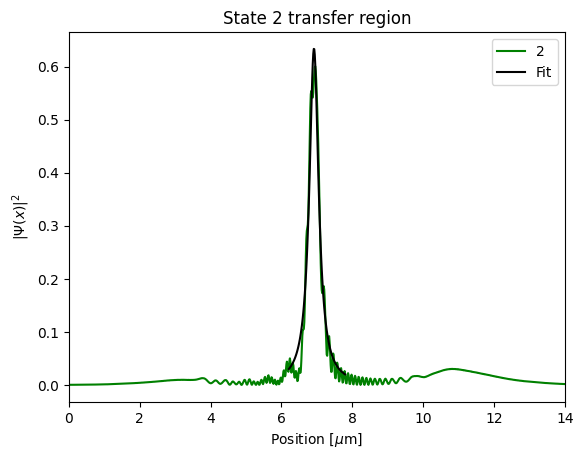

Probe max = 166.62162162162164 kHz, Coupling max = 555.4054054054055 kHz
Reflected fraction: 0.24207421296511517, Transmitted fraction: 0.757925787037032
State 1 population: 0.10617364234350642


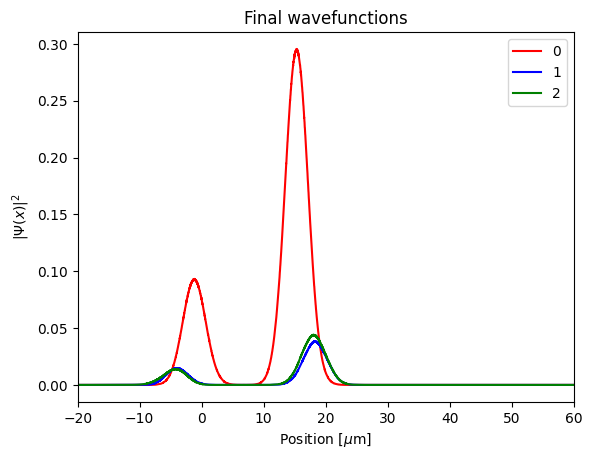

Gamma = 0.31557232565716753 um


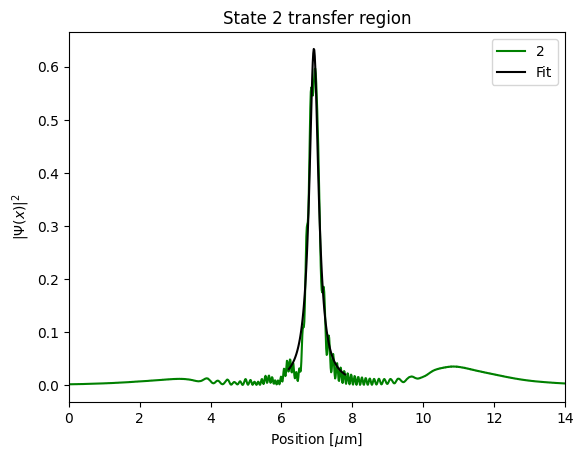

Probe max = 170.06756756756758 kHz, Coupling max = 566.8918918918919 kHz
Reflected fraction: 0.24804723000589057, Transmitted fraction: 0.751952769996247
State 1 population: 0.09476629900613406


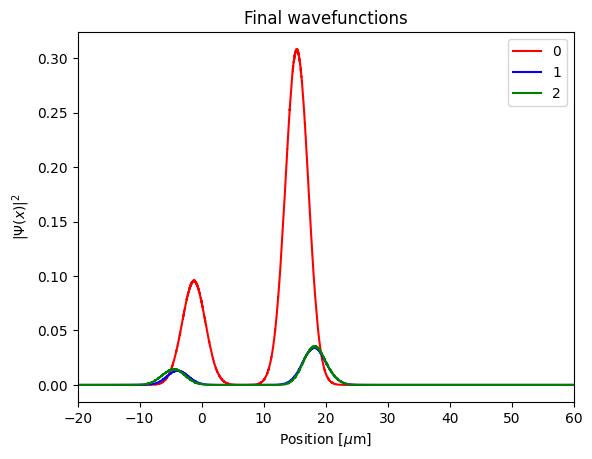

Gamma = 0.31502630369886836 um


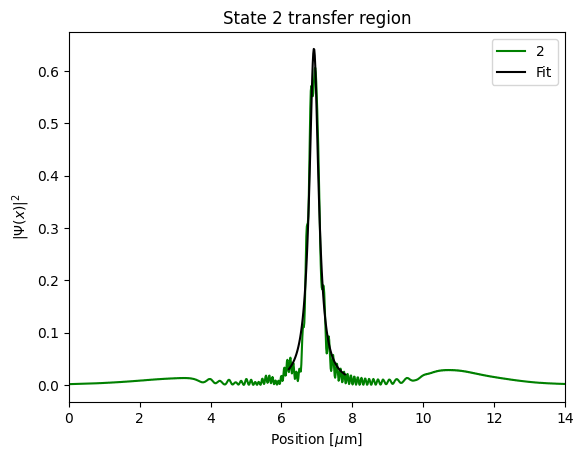

Probe max = 173.5135135135135 kHz, Coupling max = 578.3783783783783 kHz
Reflected fraction: 0.24537025624296582, Transmitted fraction: 0.7546297437591915
State 1 population: 0.0918147554429172


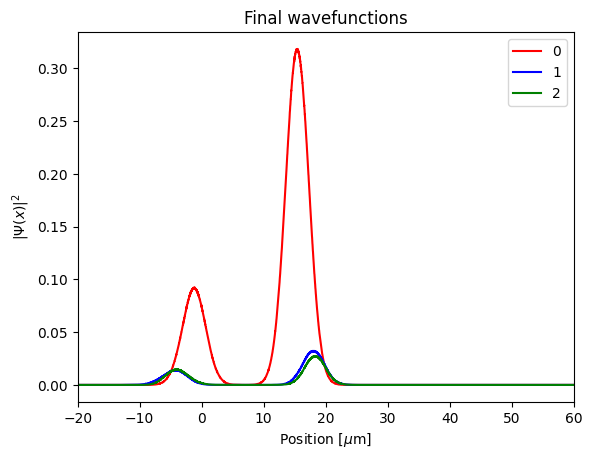

Gamma = 0.3142480299180751 um


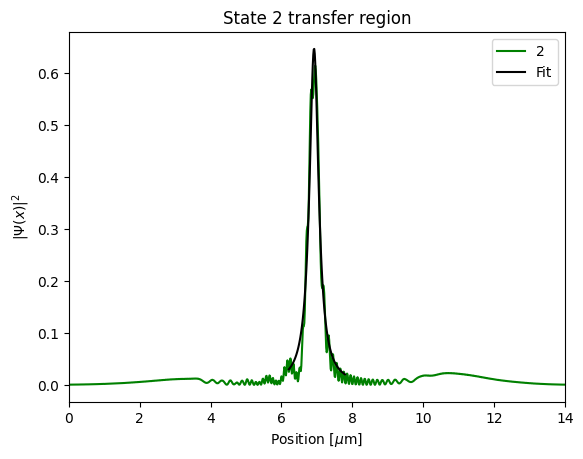

Probe max = 176.9594594594594 kHz, Coupling max = 589.8648648648648 kHz
Reflected fraction: 0.24000366324305547, Transmitted fraction: 0.7599963367590931
State 1 population: 0.09957708829868192


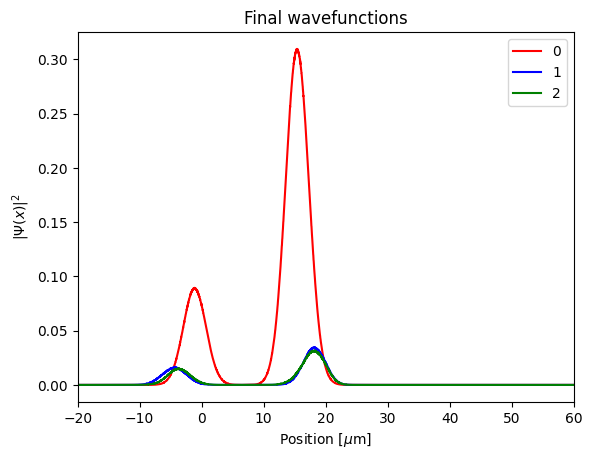

Gamma = 0.31303223008252695 um


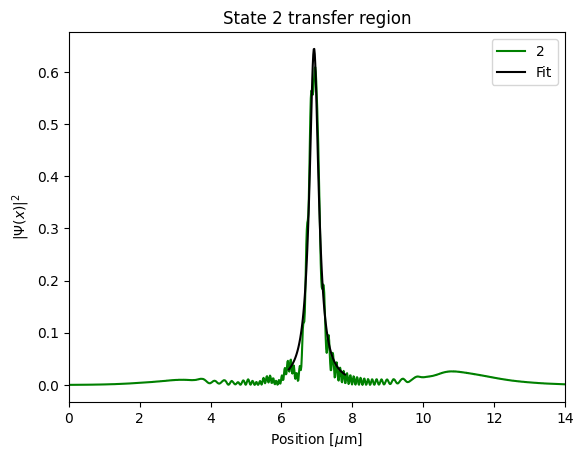

Probe max = 180.40540540540542 kHz, Coupling max = 601.3513513513514 kHz
Reflected fraction: 0.2419760972042539, Transmitted fraction: 0.758023902797884
State 1 population: 0.10178206031111936


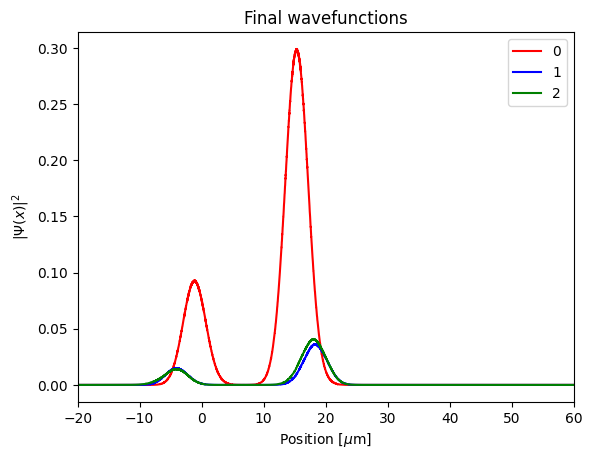

Gamma = 0.3135424436327197 um


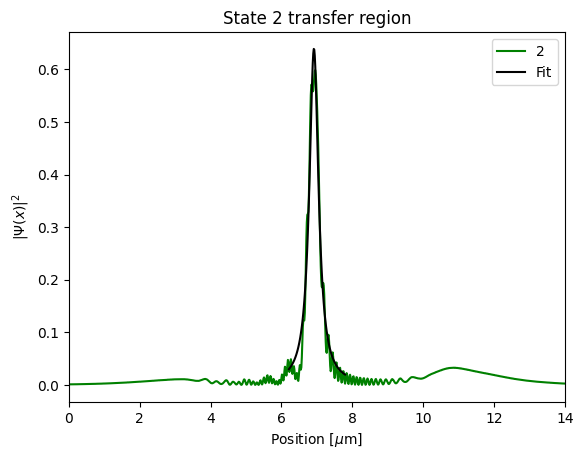

Probe max = 183.85135135135135 kHz, Coupling max = 612.8378378378378 kHz
Reflected fraction: 0.2486882750477914, Transmitted fraction: 0.7513117249543446
State 1 population: 0.09391185380316233


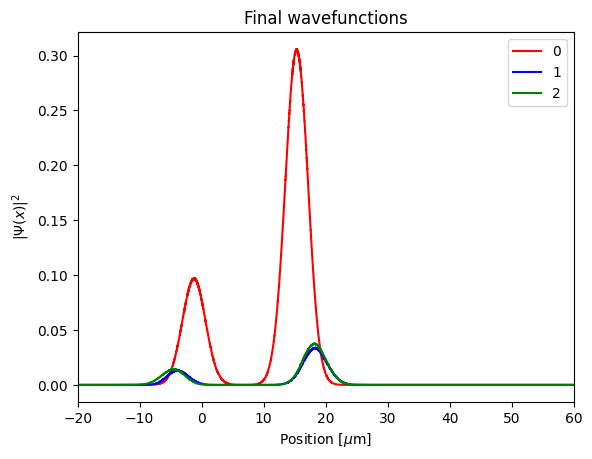

Gamma = 0.313196967144964 um


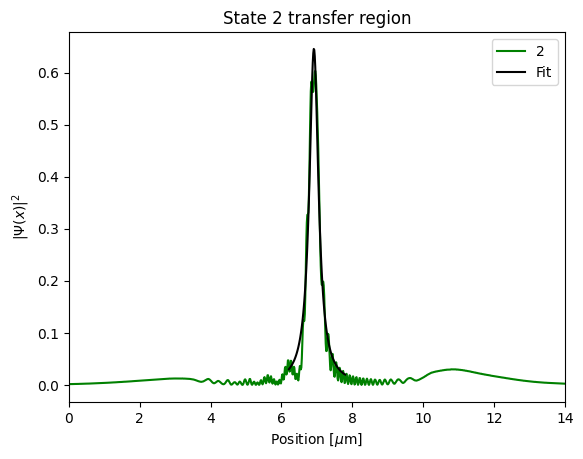

Probe max = 187.29729729729726 kHz, Coupling max = 624.3243243243243 kHz
Reflected fraction: 0.24964265175929462, Transmitted fraction: 0.7503573482428536
State 1 population: 0.08734382634113338


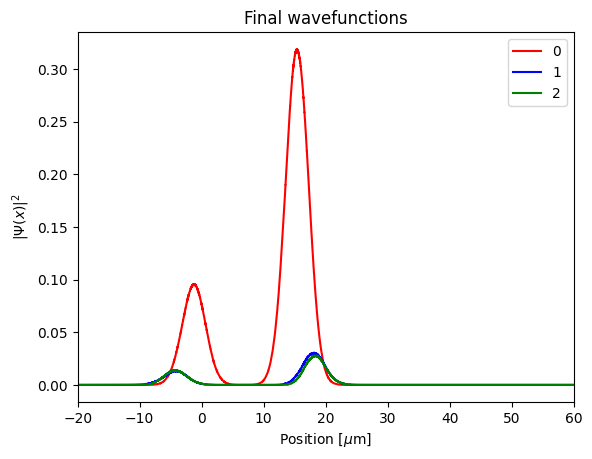

Gamma = 0.3126790072094696 um


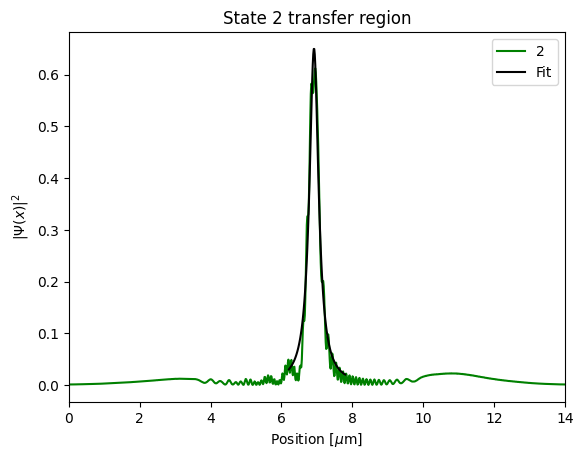

Probe max = 190.74324324324323 kHz, Coupling max = 635.810810810811 kHz
Reflected fraction: 0.24412126562745018, Transmitted fraction: 0.7558787343746922
State 1 population: 0.0913896370084531


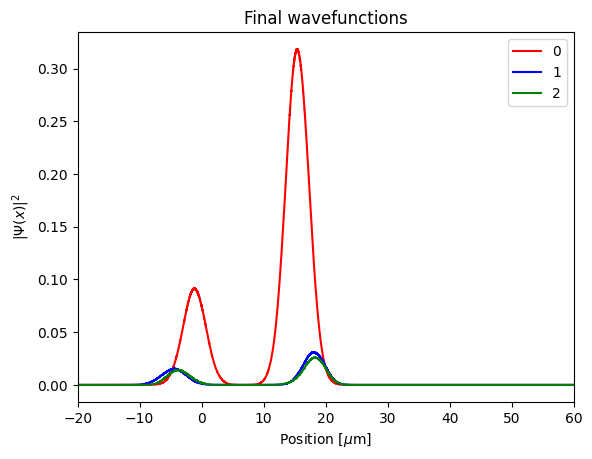

Gamma = 0.3116748173929654 um


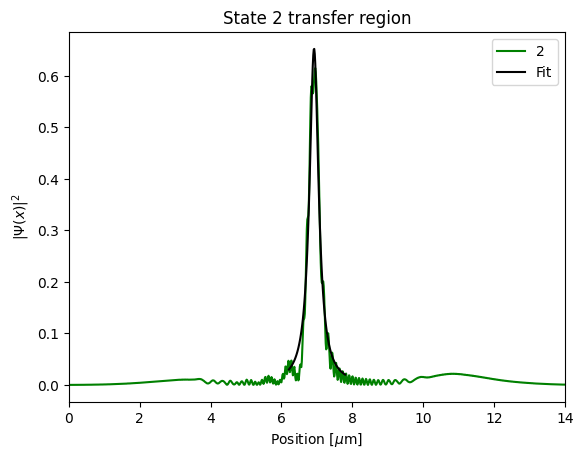

Probe max = 194.18918918918922 kHz, Coupling max = 647.2972972972974 kHz
Reflected fraction: 0.24189312095074791, Transmitted fraction: 0.758106879051408
State 1 population: 0.09626043890289888


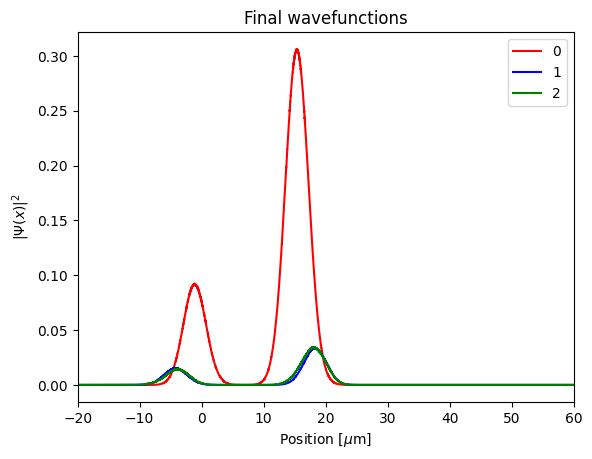

Gamma = 0.3122550993656682 um


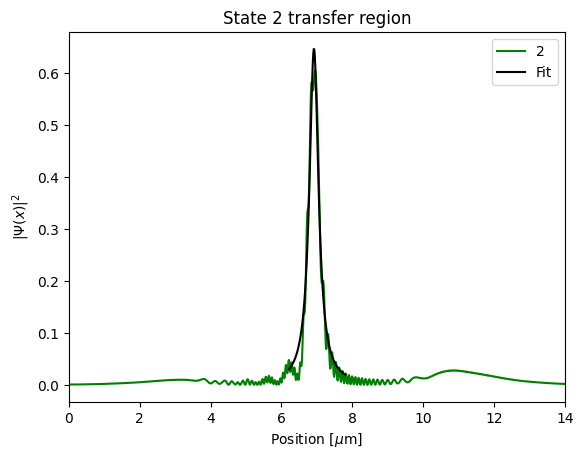

Probe max = 197.6351351351351 kHz, Coupling max = 658.7837837837837 kHz
Reflected fraction: 0.24688407731282191, Transmitted fraction: 0.7531159226893211
State 1 population: 0.09351966193430249


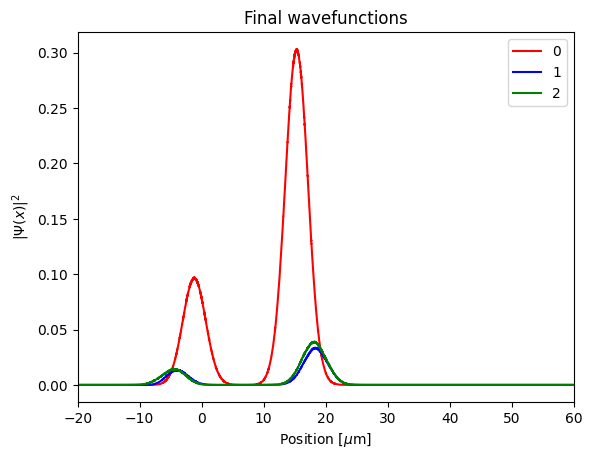

Gamma = 0.31109987184483867 um


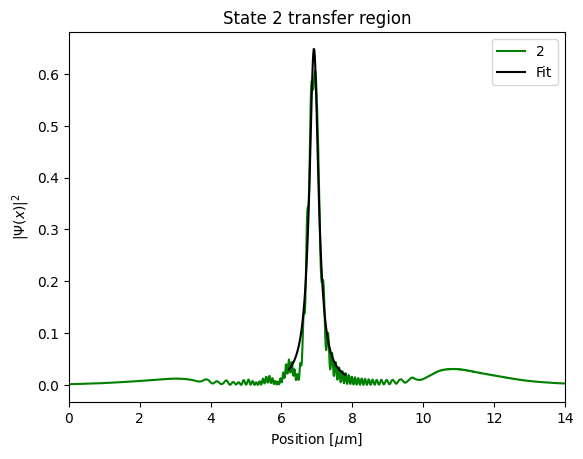

Probe max = 201.0810810810811 kHz, Coupling max = 670.2702702702702 kHz
Reflected fraction: 0.25184868171579816, Transmitted fraction: 0.7481513182863501
State 1 population: 0.08612703706154314


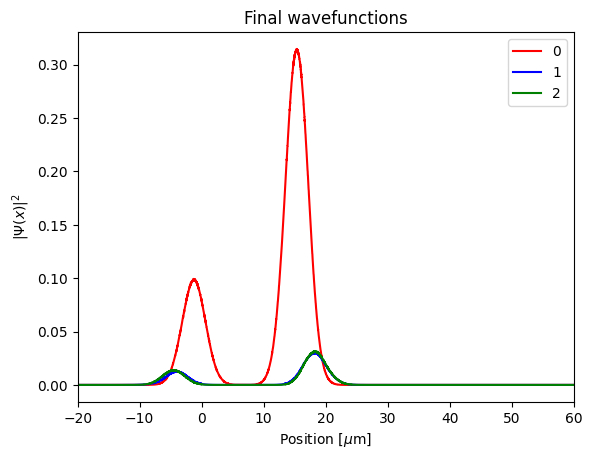

Gamma = 0.3111410102807873 um


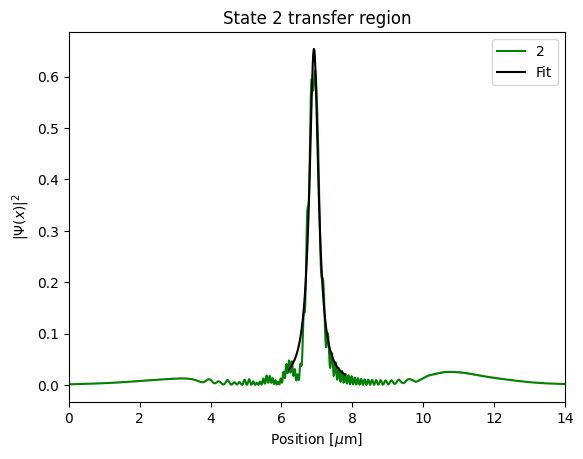

Probe max = 204.52702702702703 kHz, Coupling max = 681.7567567567569 kHz
Reflected fraction: 0.24951581217748886, Transmitted fraction: 0.7504841878246575
State 1 population: 0.08439225104525239


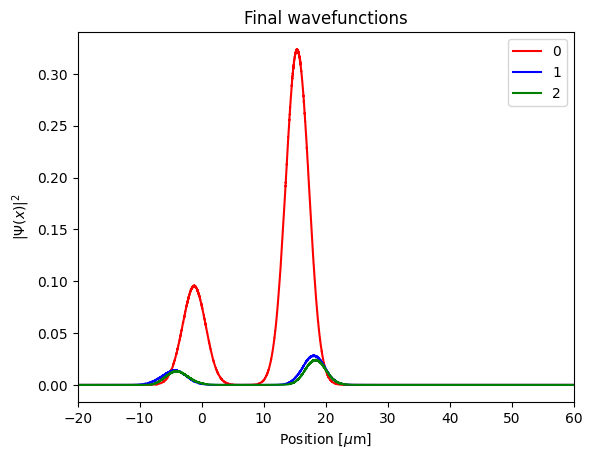

Gamma = 0.31034604019378553 um


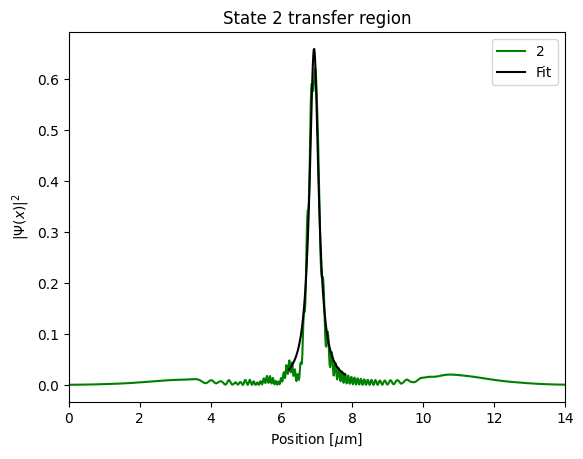

Probe max = 207.9729729729729 kHz, Coupling max = 693.2432432432431 kHz
Reflected fraction: 0.24422352183209226, Transmitted fraction: 0.7557764781700322
State 1 population: 0.08894935992551474


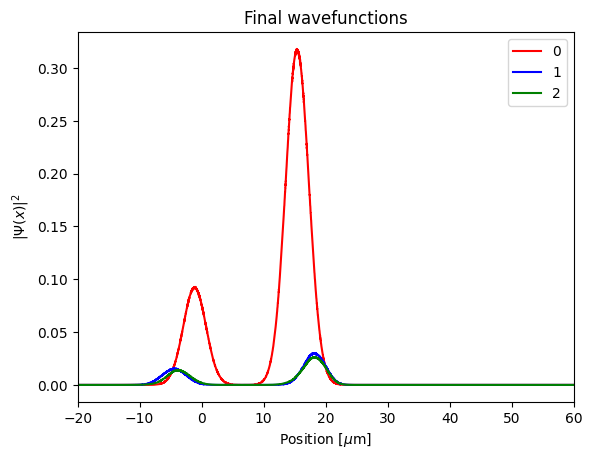

Gamma = 0.3097523115276246 um


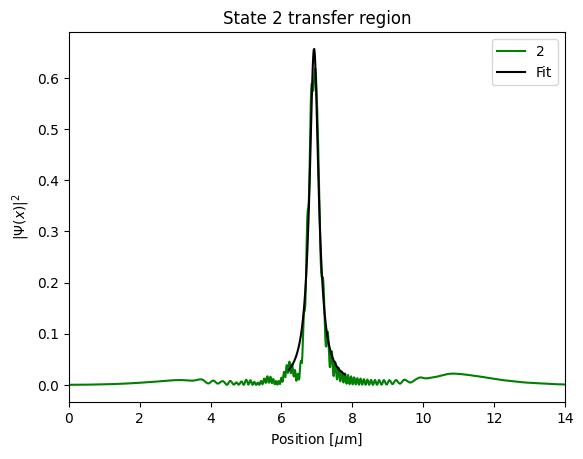

Probe max = 211.41891891891888 kHz, Coupling max = 704.7297297297297 kHz
Reflected fraction: 0.24428978200631113, Transmitted fraction: 0.7557102179958276
State 1 population: 0.09091075661281163


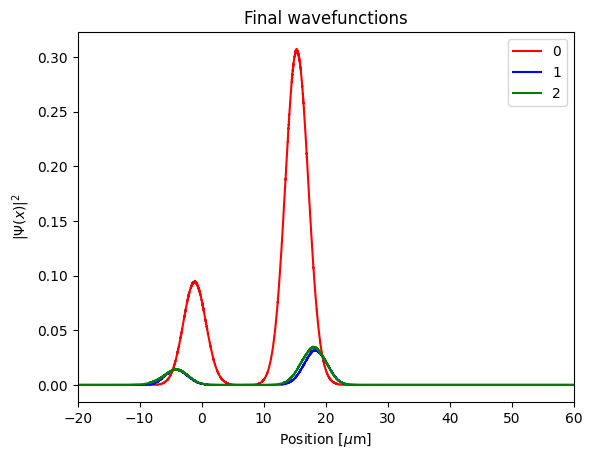

Gamma = 0.31022616355757 um


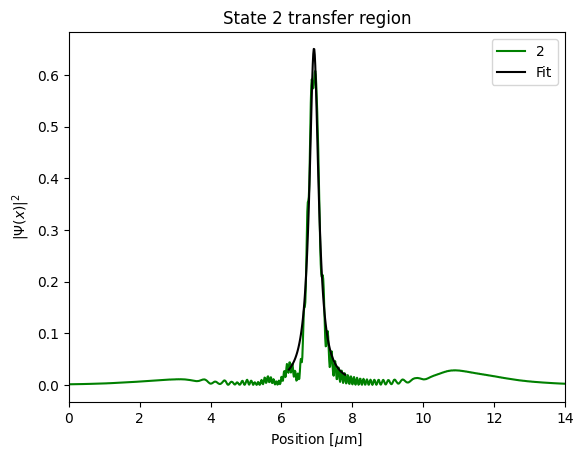

Probe max = 214.86486486486478 kHz, Coupling max = 716.2162162162161 kHz
Reflected fraction: 0.24993242330013918, Transmitted fraction: 0.750067576702017
State 1 population: 0.0871289386712551


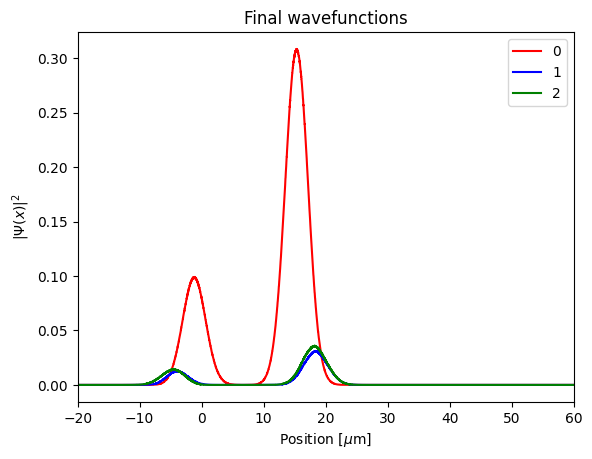

Gamma = 0.3093704492318322 um


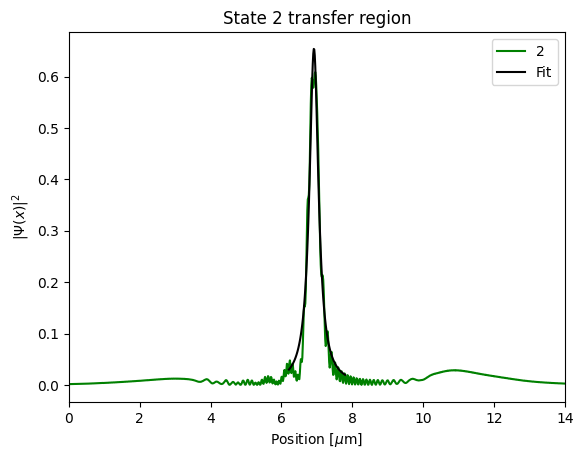

Probe max = 218.31081081081078 kHz, Coupling max = 727.7027027027027 kHz
Reflected fraction: 0.2532073635479397, Transmitted fraction: 0.7467926364542193
State 1 population: 0.08171132811477279


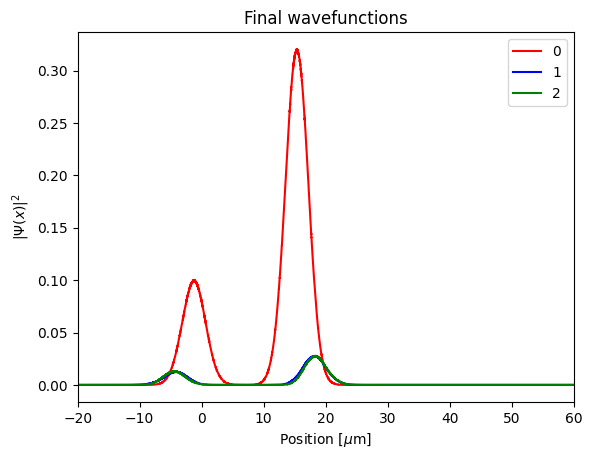

Gamma = 0.3096571174880114 um


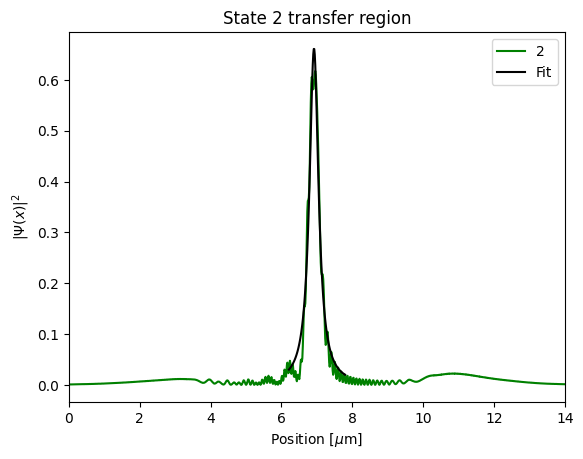

Probe max = 221.75675675675674 kHz, Coupling max = 739.1891891891892 kHz
Reflected fraction: 0.24971805027741556, Transmitted fraction: 0.7502819497247044
State 1 population: 0.08158481009936853


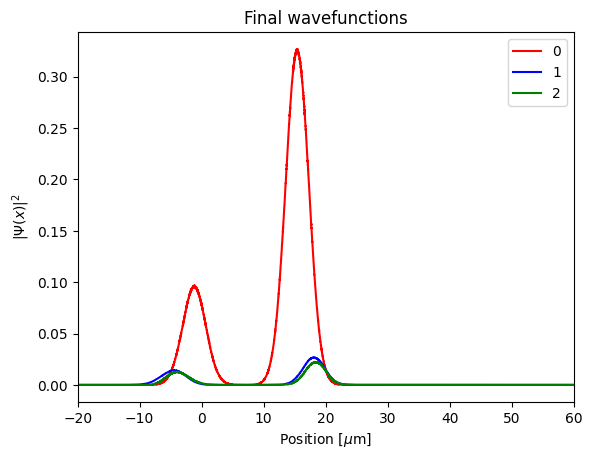

Gamma = 0.30828893032109805 um


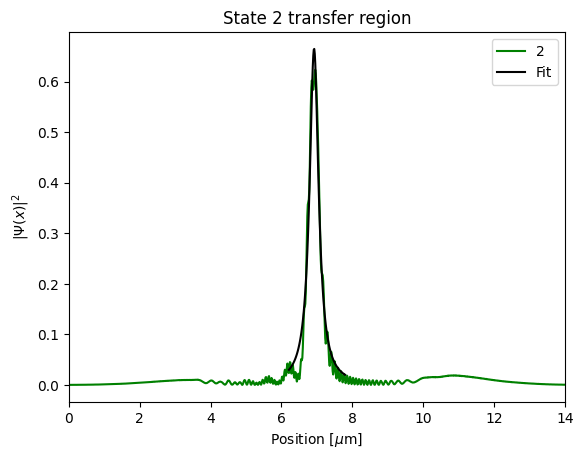

Probe max = 225.20270270270268 kHz, Coupling max = 750.6756756756757 kHz
Reflected fraction: 0.24501234139480993, Transmitted fraction: 0.754987658607331
State 1 population: 0.08490191988453101


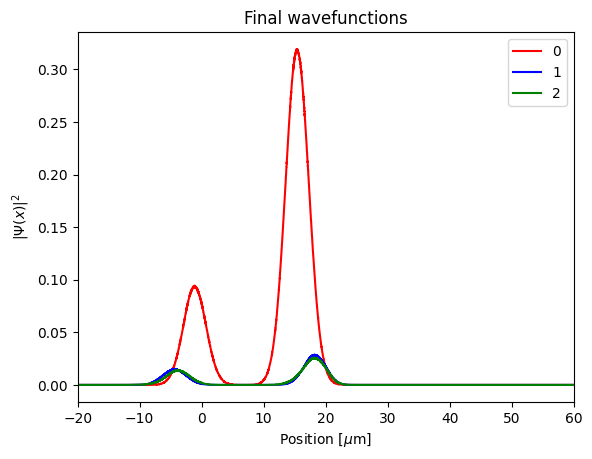

Gamma = 0.30842583612646185 um


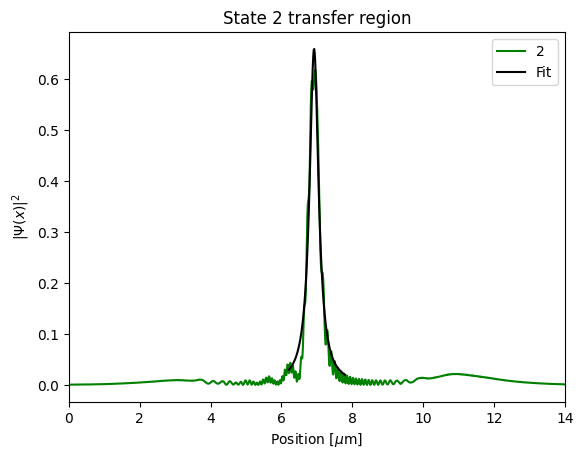

Probe max = 228.64864864864862 kHz, Coupling max = 762.162162162162 kHz
Reflected fraction: 0.24581791844799974, Transmitted fraction: 0.7541820815541181
State 1 population: 0.08580523755889909


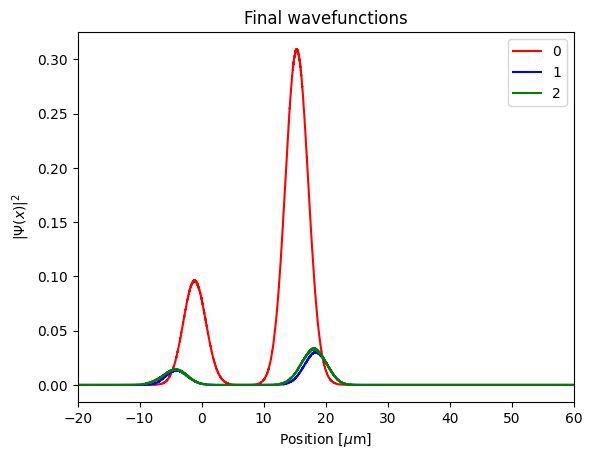

Gamma = 0.3078898209527209 um


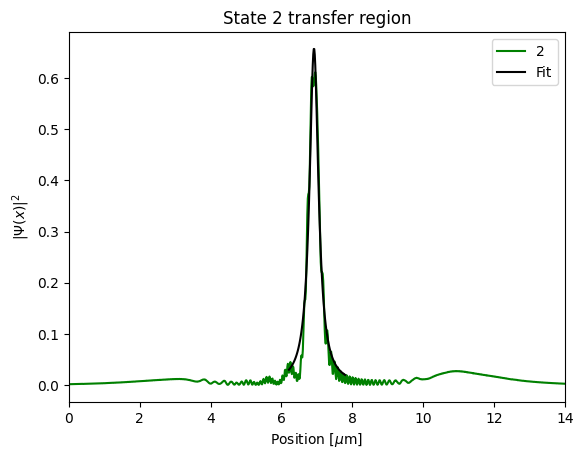

Probe max = 232.09459459459455 kHz, Coupling max = 773.6486486486488 kHz
Reflected fraction: 0.25124309976547204, Transmitted fraction: 0.7487569002366731
State 1 population: 0.08282270738099727


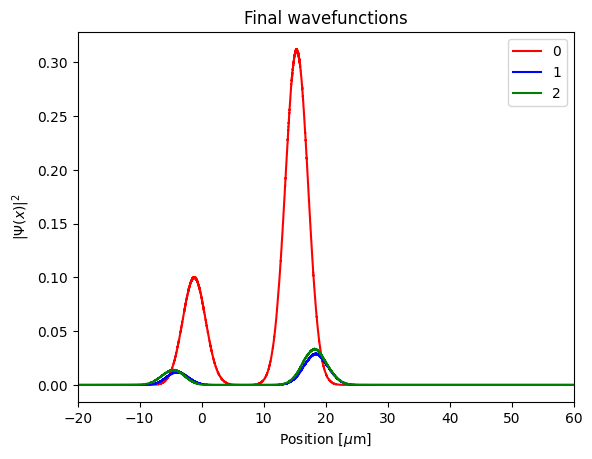

Gamma = 0.30754612685769617 um


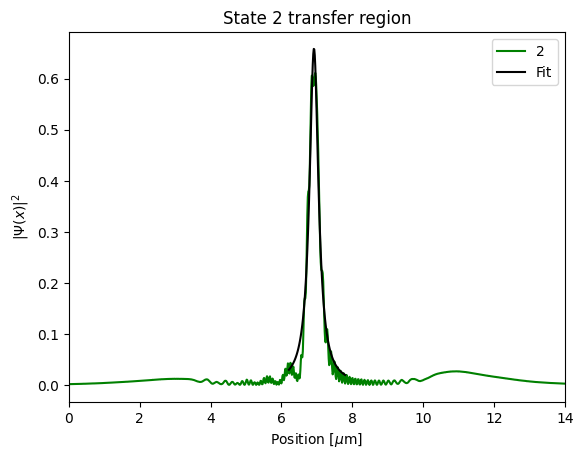

Probe max = 235.54054054054055 kHz, Coupling max = 785.1351351351352 kHz
Reflected fraction: 0.253982709108746, Transmitted fraction: 0.7460172908934337
State 1 population: 0.07874508140146841


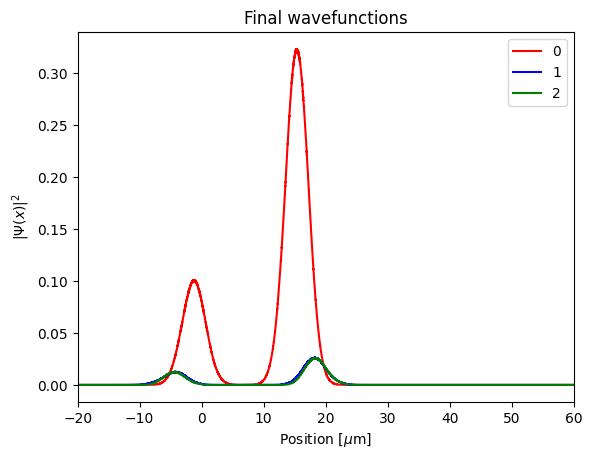

Gamma = 0.30697302669653287 um


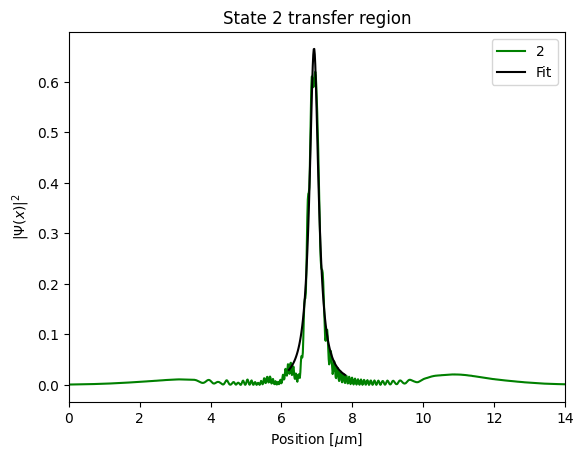

Probe max = 238.98648648648648 kHz, Coupling max = 796.6216216216216 kHz
Reflected fraction: 0.2505559861471257, Transmitted fraction: 0.7494440138550065
State 1 population: 0.07833601772155864


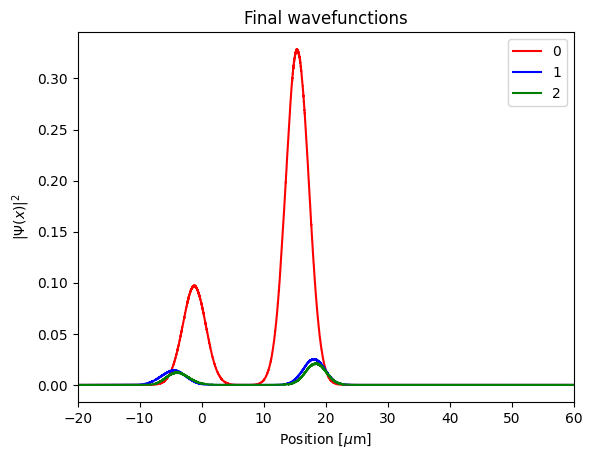

Gamma = 0.3066750124044592 um


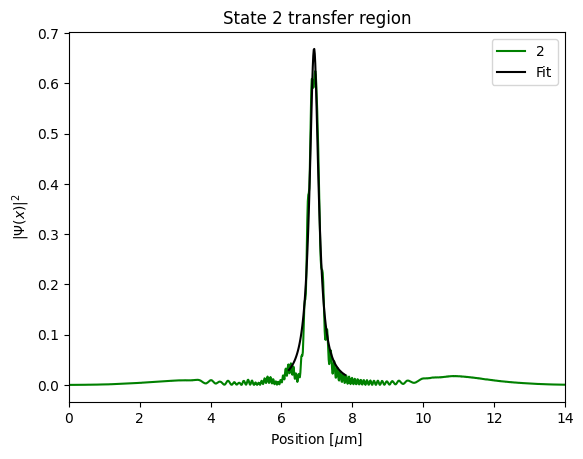

Probe max = 242.43243243243245 kHz, Coupling max = 808.1081081081081 kHz
Reflected fraction: 0.2459530442009841, Transmitted fraction: 0.754046955801164
State 1 population: 0.0804387698549004


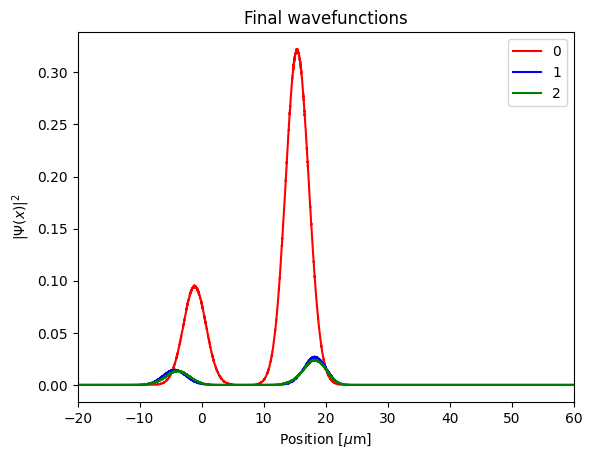

Gamma = 0.30639726634101483 um


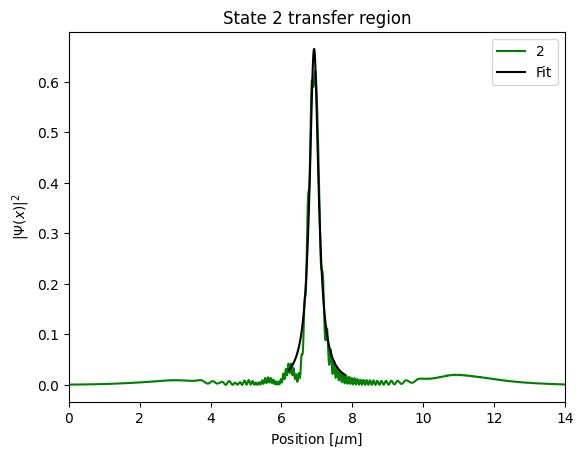

Probe max = 245.87837837837836 kHz, Coupling max = 819.5945945945945 kHz
Reflected fraction: 0.24624166893750996, Transmitted fraction: 0.753758331064653
State 1 population: 0.08133952193924902


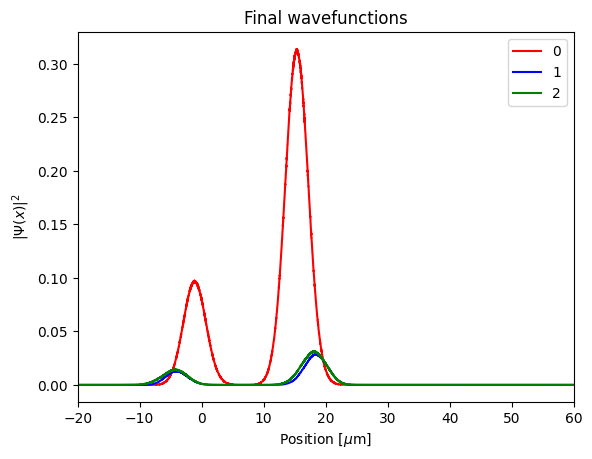

Gamma = 0.3059894196660937 um


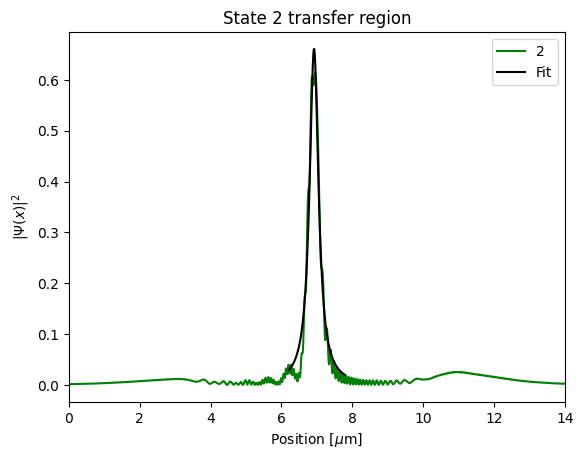

Probe max = 249.3243243243243 kHz, Coupling max = 831.0810810810812 kHz
Reflected fraction: 0.2511679367661022, Transmitted fraction: 0.7488320632360232
State 1 population: 0.0796619171898933


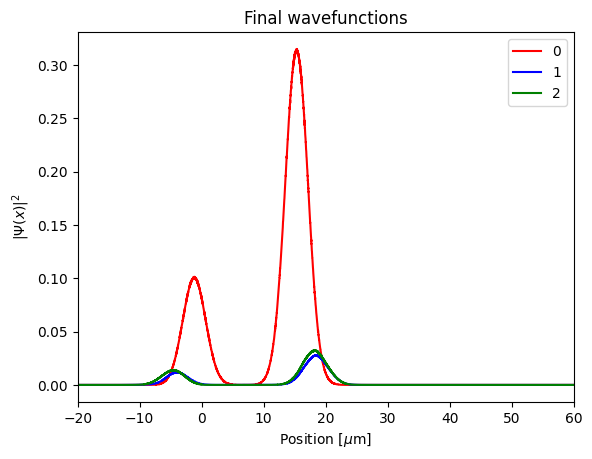

Gamma = 0.30480062496484484 um


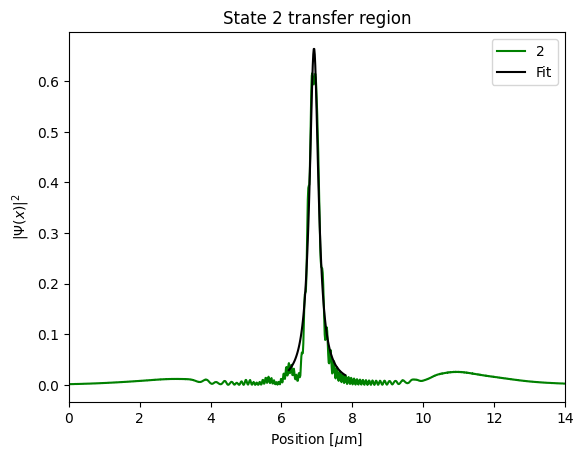

Probe max = 252.77027027027026 kHz, Coupling max = 842.5675675675675 kHz
Reflected fraction: 0.2544209981764534, Transmitted fraction: 0.7455790018256444
State 1 population: 0.07638928643667219


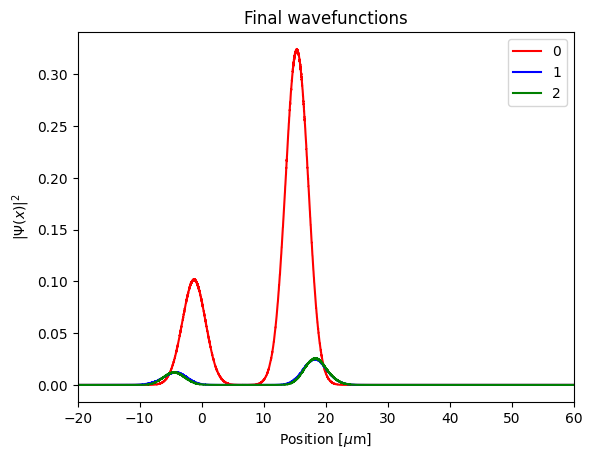

Gamma = 0.3046990873790077 um


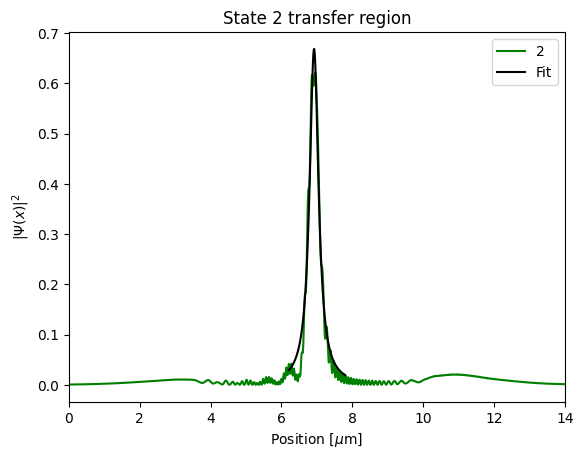

Probe max = 256.2162162162162 kHz, Coupling max = 854.0540540540542 kHz
Reflected fraction: 0.2519299278057635, Transmitted fraction: 0.7480700721964455
State 1 population: 0.07510830743597503


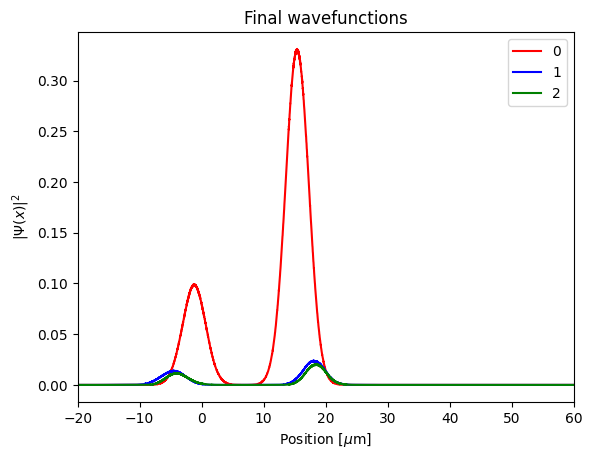

Gamma = 0.30410797272799367 um


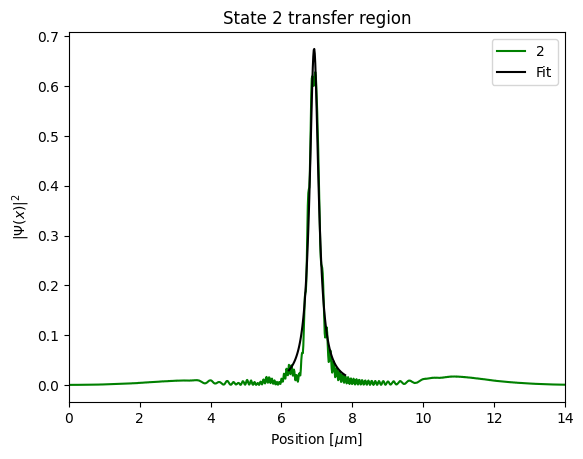

Probe max = 259.66216216216213 kHz, Coupling max = 865.5405405405404 kHz
Reflected fraction: 0.24713879413690523, Transmitted fraction: 0.7528612058652574
State 1 population: 0.07616671684039014


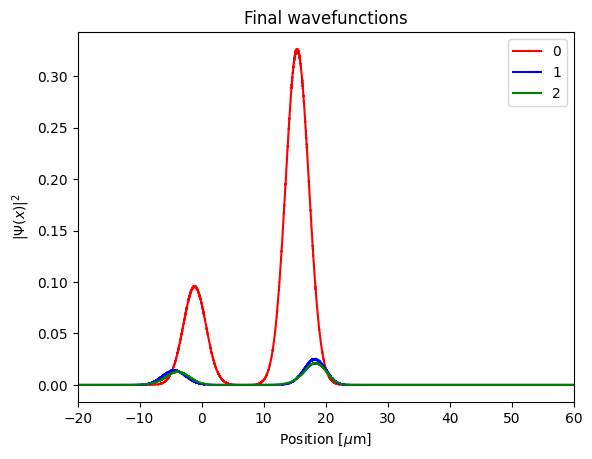

Gamma = 0.3033937540662837 um


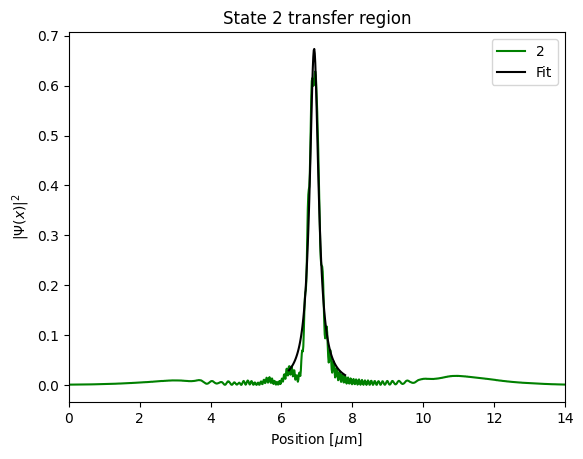

Probe max = 263.10810810810807 kHz, Coupling max = 877.0270270270271 kHz
Reflected fraction: 0.24594451006641427, Transmitted fraction: 0.7540554899357435
State 1 population: 0.07714022163750997


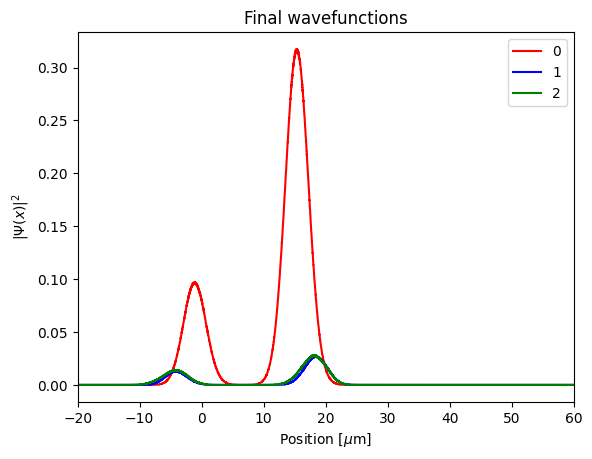

Gamma = 0.3040669786532314 um


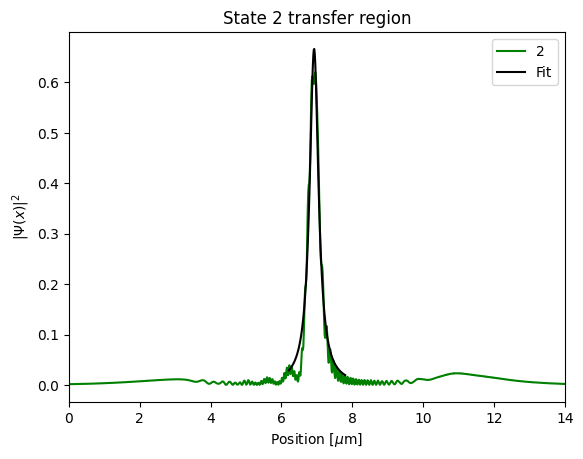

Probe max = 266.554054054054 kHz, Coupling max = 888.5135135135134 kHz
Reflected fraction: 0.2497903070782327, Transmitted fraction: 0.7502096929239348
State 1 population: 0.07692979264417557


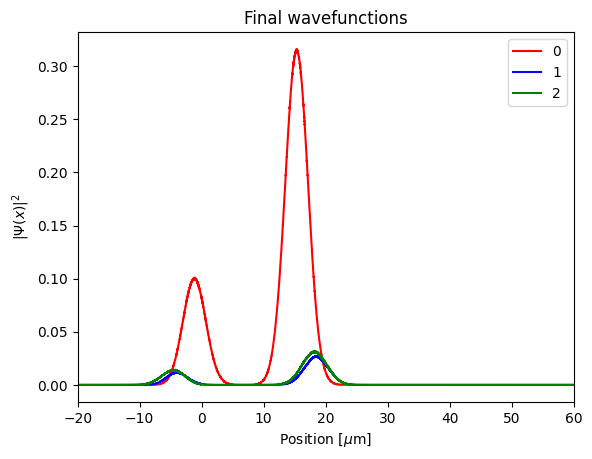

Gamma = 0.3030444847299109 um


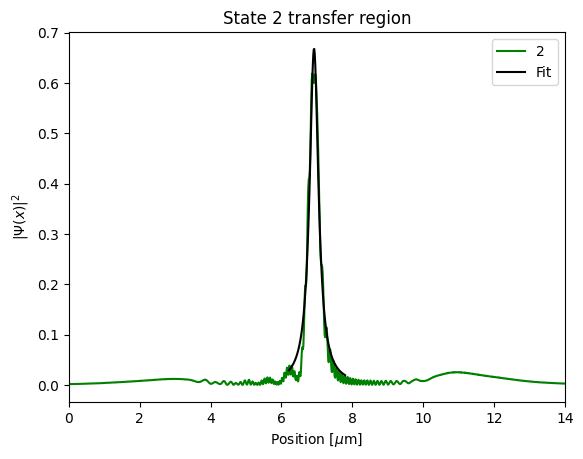

Probe max = 270.0 kHz, Coupling max = 900.0 kHz
Reflected fraction: 0.2540204450671618, Transmitted fraction: 0.7459795549349969
State 1 population: 0.07474369681401073


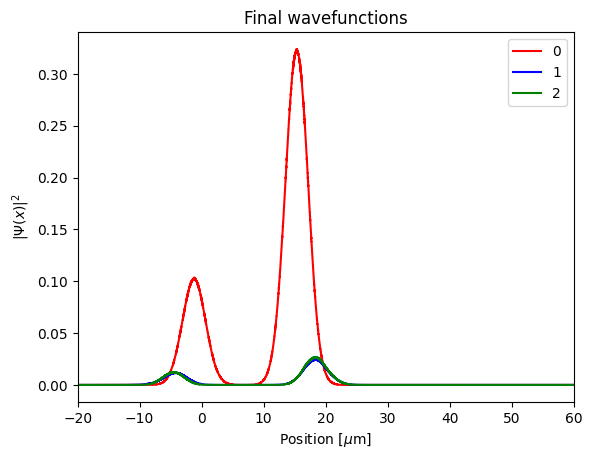

Gamma = 0.30256031102607633 um


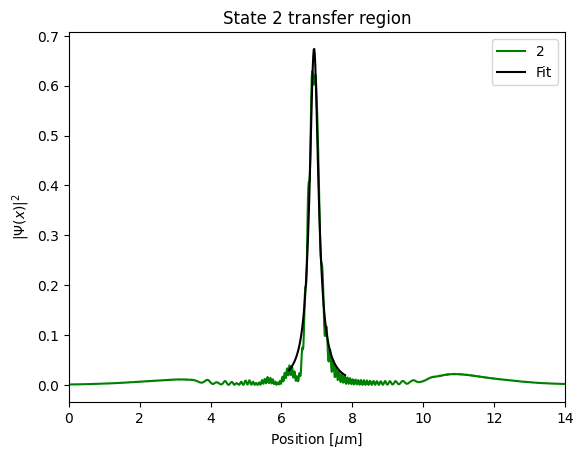

In [11]:
# Look at localization as a function of the two max rabi frequencies

def TEM01(x, x0, sigma, Omega_max):
    return Omega_max**2 * 2 * ((x-x0)/sigma)**2 * np.exp(1 - 2*((x-x0)/sigma)**2)

def gaussian(x, x0, sigma, Omega_max):
    return Omega_max**2 * np.exp(-2*(x-x0)**2 / sigma**2)

def lorentzian(x, x0, A, gamma):
    return A * (gamma/2)**2 / ((x-x0)**2 + (gamma/2)**2)

# rabi drives
scan_dim = 75
rabi_ratio = 0.3
coupling_max_arr = 2 * np.pi * np.linspace(50,900,scan_dim) * 1e3 * time_scale
probe_max_arr = rabi_ratio * coupling_max_arr
sigma = 1.3e-6

# rabi_probe = probe_max * np.exp(-((X_real-20e-6))**2 / (2*1.3e-6)**2)
# rabi_coupling = coupling_max * (np.exp(-((X_real-20e-6+2.5*1.3e-6))**2 / (1.3e-6)**2) + np.exp(-((X_real-20e-6-2.5*1.3e-6))**2 / (1.3e-6)**2))

# rabi_probe = probe_max * np.exp(-((X_real-21e-6))**2 / (1.3e-6)**2)
# rabi_coupling = coupling_max * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2)

# hold_time = 2.5e-3 / time_scale
# dt_hold = 5e-4
# # hold_time_steps * dt_hold * time_scale = 2.5 ms

# kick strength
v_kick = 4e-3
k_kick = m_rb * v_kick * length_scale / hbar
psi_kicked = psi_ground * np.exp(1j * k_kick * X)

tun_time = 4e-3 / time_scale
dt_tun = 2e-4
tun_timesteps = int(tun_time / dt_tun)

U = np.zeros((3, len(X)))

# U_tun = np.zeros((3, len(X)))
# U_tun[0] = (m_rb * (5e-3)**2 / 2) * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2) / energy_scale


plt.plot(X * length_scale * 1e6, np.real(psi_kicked[0]*np.conj(psi_kicked[0])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_kicked[1]*np.conj(psi_kicked[1])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_kicked[2]*np.conj(psi_kicked[2])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.xlim([-40,40])
plt.title("Initial wavefunction")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

all_x0 = np.zeros(scan_dim)
all_A = np.zeros(scan_dim)
all_gamma = np.zeros(scan_dim)
all_1_pops = np.zeros(scan_dim)
all_reflected_fractions = np.zeros(scan_dim)

X_fit = np.array([])
for j in range(len(X_real)):
    if X_real[j] >= 6.2e-6 and X_real[j] <= 7.8e-6:
        X_fit = np.append(X_fit, X_real[j])

for i in range(len(coupling_max_arr)):

    rabi_probe = np.sqrt(gaussian(X_real, 7e-6, sigma, probe_max_arr[i]))
    rabi_coupling = np.sqrt(TEM01(X_real, 7e-6, sigma, coupling_max_arr[i]))
        
    (K_tun, T_tun, psi_tun, ep, energies_tun) = gpe1d(epsilon=epsilon, kappa=kappa, 
                              Omega=rabi_probe, Omega_2=rabi_coupling,
                              N=tun_timesteps, 
                              k=dt_tun, X=X, U=U, psi0=psi_kicked, Ntstore=100, 
                              imag_time=0, error=0.0002) 

    max_2_pop = 0
    max_index = 0
    
    for index in range(len(T_tun)):
        psi2_partial = np.array([])
        for j in range(len(X_real)):
            if X_real[j] >= 6.2e-6 and X_real[j] <= 7.8e-6:
                psi2_partial = np.append(psi2_partial, psi_tun[2][index][j])                     
        if np.sum(np.real(psi2_partial*np.conj(psi2_partial))*dx) > max_2_pop:
            max_2_pop = np.sum(np.real(psi2_partial*np.conj(psi2_partial)))*dx
            max_index = index
            psi2_partial_max = psi2_partial
    
    print("Probe max = " + str(probe_max_arr[i] / 1e3 / time_scale / (2*np.pi)) + " kHz, Coupling max = " + str(coupling_max_arr[i] / 1e3 / time_scale / (2*np.pi)) + " kHz")    

    p0_guesses = [7e-6, np.max(np.real(psi2_partial_max*np.conj(psi2_partial_max))), sigma/4]
    popt, pcov = curve_fit(lorentzian, X_fit, np.real(psi2_partial_max*np.conj(psi2_partial_max)), p0=p0_guesses, maxfev=20000)

    x0_fit, A_fit, gamma_fit = popt
    
    all_x0[i] = x0_fit
    all_A[i] = np.abs(A_fit)
    all_gamma[i] = np.abs(gamma_fit)

    reflected = np.array([])
    transmitted = np.array([])
    
    for k in range(len(X)):
        
        if X_real[k] <= 7e-6:
            reflected = np.append(reflected, (np.real(psi_tun[0][-1][k] * np.conj(psi_tun[0][-1][k]))+np.real(psi_tun[1][-1][k] * np.conj(psi_tun[1][-1][k]))+np.real(psi_tun[2][-1][k] * np.conj(psi_tun[2][-1][k])))*dx)
        else:
            transmitted = np.append(transmitted, (np.real(psi_tun[0][-1][k] * np.conj(psi_tun[0][-1][k]))+np.real(psi_tun[1][-1][k] * np.conj(psi_tun[1][-1][k]))+np.real(psi_tun[2][-1][k] * np.conj(psi_tun[2][-1][k])))*dx)
    
    print("Reflected fraction: " + str(np.sum(reflected)) + ", Transmitted fraction: " + str(np.sum(transmitted)))

    all_reflected_fractions[i] = np.sum(reflected)

    print("State 1 population: " + str(np.sum(np.real(psi_tun[1][-1] * np.conj(psi_tun[1][-1])))*dx))
    # print("Expected state 1 population: " + str(np.exp(-(np.pi*sigma/2/4e-3) * np.sqrt(probe_max_arr[i]**2/time_scale/2/np.e/coupling_max_arr[i]))))

    all_1_pops[i] = np.sum(np.real(psi_tun[1][-1] * np.conj(psi_tun[1][-1])))*dx
    
    plt.plot(X * length_scale * 1e6, np.real(psi_tun[0][-1]*np.conj(psi_tun[0][-1])), color='red', label="0")
    plt.plot(X * length_scale * 1e6, np.real(psi_tun[1][-1]*np.conj(psi_tun[1][-1])), color='blue', label="1")
    plt.plot(X * length_scale * 1e6, np.real(psi_tun[2][-1]*np.conj(psi_tun[2][-1])), color='green', label="2")
    plt.xlabel(r'Position [$\mu$m]')
    plt.ylabel(r'$|\Psi(x)|^2$')
    plt.xlim([-20,60])
    plt.title("Final wavefunctions")
    # plt.axvline(27.8, color='black', linestyle='--')
    plt.legend()  
    plt.show()
    
    print("Gamma = " + str(all_gamma[i]*1e6) + " um")
    
    plt.plot(X * length_scale * 1e6, np.real(psi_tun[2][max_index]*np.conj(psi_tun[2][max_index])), color='green', label="2")
    plt.plot(X_fit * 1e6, lorentzian(X_fit, *popt), color = "black", label = "Fit")
    plt.xlabel(r'Position [$\mu$m]')
    plt.ylabel(r'$|\Psi(x)|^2$')
    plt.xlim([0,14])
    plt.title("State 2 transfer region")
    # plt.axvline(27.8, color='black', linestyle='--')
    plt.legend()  
    plt.show()

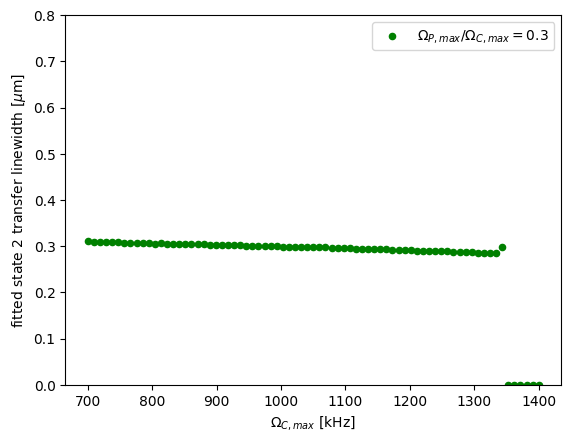

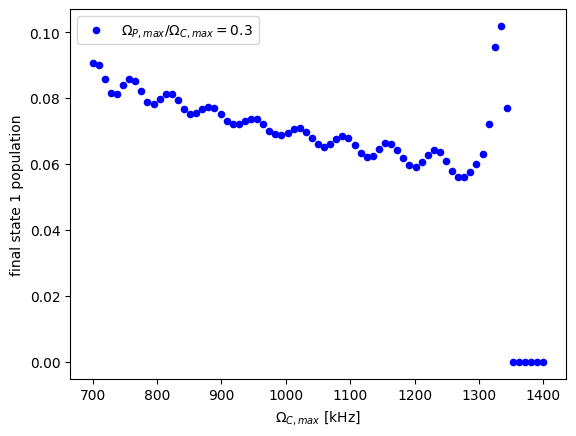

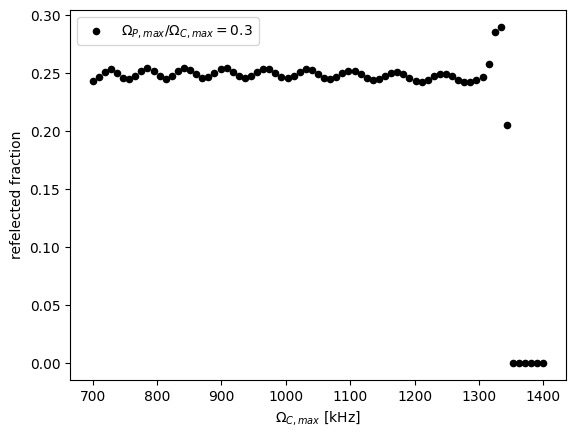

In [10]:
# for rabi_ratio = 0.35, Coupling max = 514.2857142857142 kHz and Coupling max = 407.14285714285717 kHz are decent
# for rabi_ratio = 0.4, Coupling max = 364.2857142857143 kHz, Coupling max = 428.5714285714285 kHz are decent

plt.scatter(coupling_max_arr / time_scale / 1e3 / (2*np.pi), all_gamma*1e6, color='green', label=r"$\Omega_{P,max}/\Omega_{C,max}=$"+str(rabi_ratio), s=20)
plt.xlabel(r'$\Omega_{C,max}$ [kHz]')
plt.ylabel(r'fitted state 2 transfer linewidth [$\mu$m]')
# plt.title('$v=$' + str(v_kick*1e3) " mm/s")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.ylim(0,0.8)
plt.savefig("C:\\Users\\n0ahb\\OneDrive\\Documents\\PhD\\Codes\\Figures\\eit_localization_plots\\TEM01 + gaussian\\linewidths_v_OmegaC\\v="+str(v_kick*1e3)+"mmps_r="+str(rabi_ratio)+".png")
plt.show()

plt.scatter(coupling_max_arr / time_scale / 1e3 / (2*np.pi), all_1_pops, color='blue', label=r"$\Omega_{P,max}/\Omega_{C,max}=$"+str(rabi_ratio), s=20)
plt.xlabel(r'$\Omega_{C,max}$ [kHz]')
plt.ylabel(r'final state 1 population')
# plt.title("$v=$" + str(v_kick*1e3) " mm/s")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.savefig("C:\\Users\\n0ahb\\OneDrive\\Documents\\PhD\\Codes\\Figures\\eit_localization_plots\\TEM01 + gaussian\\1pops_v_OmegaC\\v="+str(v_kick*1e3)+"mmps_r="+str(rabi_ratio)+".png")
plt.show()

plt.scatter(coupling_max_arr / time_scale / 1e3 / (2*np.pi), all_reflected_fractions, color='black', label=r"$\Omega_{P,max}/\Omega_{C,max}=$"+str(rabi_ratio), s=20)
plt.xlabel(r'$\Omega_{C,max}$ [kHz]')
plt.ylabel(r'refelected fraction')
# plt.title(r"$v=$" + str(v_kick*1e3) " mm/s")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend() 
plt.savefig("C:\\Users\\n0ahb\\OneDrive\\Documents\\PhD\\Codes\\Figures\\eit_localization_plots\\TEM01 + gaussian\\R_v_OmegaC\\v="+str(v_kick*1e3)+"mmps_r="+str(rabi_ratio)+".png")
plt.show()

[[7.32531699e-07 1.48262959e-06 2.72577847e-07 3.07336347e-07
  2.95141457e-07]
 [6.76453448e-07 3.25428171e-07 7.99809044e-07 3.41632569e-07
  3.14431354e-07]
 [6.09158031e-07 5.41361763e-07 2.72614550e-07 2.10317091e-07
  8.66908313e-05]
 [5.22313014e-07 8.69515611e-07 2.52333128e-07 2.27676338e-07
  2.49386553e-07]
 [4.30401951e-07 1.69910010e-06 2.77167973e-07 2.75314239e-07
  2.23926714e-04]]


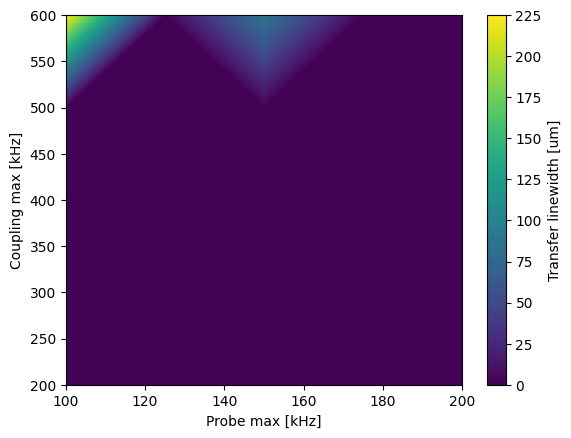

In [111]:
print(all_gamma)

X_cont, Y_cont = np.meshgrid(probe_max_arr, coupling_max_arr)

plt.contourf(X_cont / 1e3 / time_scale / (2*np.pi), Y_cont / 1e3 / time_scale / (2*np.pi), all_gamma.T * 1e6, 100,  cmap='viridis')

plt.colorbar(label = r'Transfer linewidth [um]')

# contour_line = plt.contour(X, Y, all_gamma.T * 1e6, levels=[1], colors='white', linewidths=1.3e-6)
# plt.clabel(contour_line, fmt=f'{1}')
plt.ylabel(r'Coupling max [kHz]')
plt.xlabel('Probe max [kHz]')
plt.show()

In [103]:
k_kick = m_rb * 5.1e-3 * length_scale / hbar
psi_kicked = psi_ground * np.exp(1j * k_kick * X)

k_kick = m_rb * 5.1e-3 * length_scale / hbar
psi_kicked = psi_ground * np.exp(1j * k_kick * X)

tun_time = 10e-3 / time_scale
dt_tun = 5e-4
tun_timesteps = int(tun_time / dt_tun)

U_tun = np.zeros((3, len(X)))
U_tun[0] = (m_rb * (5.1e-3)**2 / 2) * np.exp(-((X_real-20e-6))**2 / (1.3e-6)**2) / energy_scale

probe_centers = np.linspace(20e-6-2*1.3e-6, 20e-6+2*1.3e-6, 20)
print("Probe centers: " + str(probe_centers))

prob_ratios_0 = np.zeros(len(probe_centers))
prob_ratios_1 = np.zeros(len(probe_centers))

for i in range(len(probe_centers)):
    
    rabi_barrier = rabi * np.exp(-((X_real-probe_centers[i]))**2 / (0.13e-6)**2)
    
    (K_tun, T_tun, psi_tun, ep, energies_tun) = gpe1d(epsilon=epsilon, kappa=kappa, 
                              Omega=rabi_barrier, Omega_2=0.0,
                              N=tun_timesteps, 
                              k=dt_tun, X=X, U=U_tun, psi0=psi_kicked, Ntstore=2, 
                              imag_time=0, error=0.0002)

    reflected_0 = np.array([])
    transmitted_0 = np.array([])
    reflected_1 = np.array([])
    transmitted_1 = np.array([])
    
    for j in range(len(X)):
        if X_real[j] < 20e-6:
            reflected_0 = np.append(reflected_0, np.real(psi_tun[0][-1][j] * np.conj(psi_tun[0][-1][j]))*dx)
            reflected_1 = np.append(reflected_1, np.real(psi_tun[1][-1][j] * np.conj(psi_tun[1][-1][j]))*dx)
        else:
            transmitted_0 = np.append(transmitted_0, np.real(psi_tun[0][-1][j] * np.conj(psi_tun[0][-1][j]))*dx)
            transmitted_1 = np.append(transmitted_1, np.real(psi_tun[1][-1][j] * np.conj(psi_tun[1][-1][j]))*dx)
            
    prob_ratios_0[i] = np.sum(transmitted_0) / np.sum(reflected_0)
    prob_ratios_1[i] = np.sum(transmitted_1) / np.sum(reflected_1)
    
    print("Reflected fraction: " + str(np.sum(reflected)) + ", Transmitted fraction: " + str(np.sum(transmitted)))
    
# For the case of a TEM01 coupling intensity profile given by I_{TEM01} = I_{max,C} * 2 * (2/\sigma)^2 * exp(1-2*(x/\sigma)^2) and a Gaussian probe
# intensity profile given by I_{G} = I_{max,P} * exp(-2(x/\sigma)^2), with \sigma = 1.3um being the 1/e^2 radius of the Gaussian profile, provide a
# detailed derivation of non-adiabatic coupling to the bright state, i.e., provide an exact expression for P_{\ket{1}} which depends on \sigma, the 
# incident velocity v, and the two maximum intensity values.

Probe centers: [1.74000000e-05 1.76736842e-05 1.79473684e-05 1.82210526e-05
 1.84947368e-05 1.87684211e-05 1.90421053e-05 1.93157895e-05
 1.95894737e-05 1.98631579e-05 2.01368421e-05 2.04105263e-05
 2.06842105e-05 2.09578947e-05 2.12315789e-05 2.15052632e-05
 2.17789474e-05 2.20526316e-05 2.23263158e-05 2.26000000e-05]
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fraction: 0.0008527219238730479
Reflected fraction: 0.00034696321413679406, Transmitted fractio

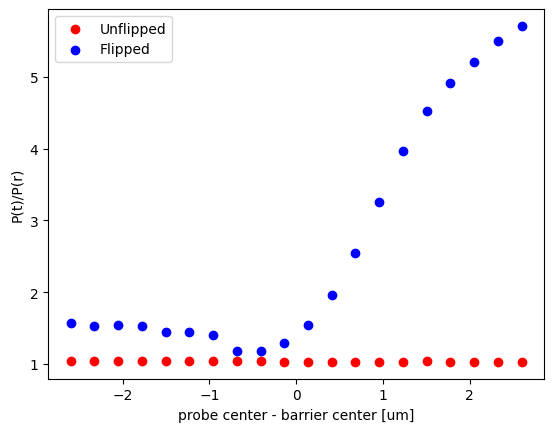

In [104]:
plt.scatter((probe_centers - 20e-6)*1e6, prob_ratios_0, color = 'red', marker = "o", label = "Unflipped")
plt.scatter((probe_centers - 20e-6)*1e6, prob_ratios_1, color = 'blue', marker = "o", label = "Flipped")
plt.xlabel("probe center - barrier center [um]")
plt.ylabel("P(t)/P(r)")
plt.legend()

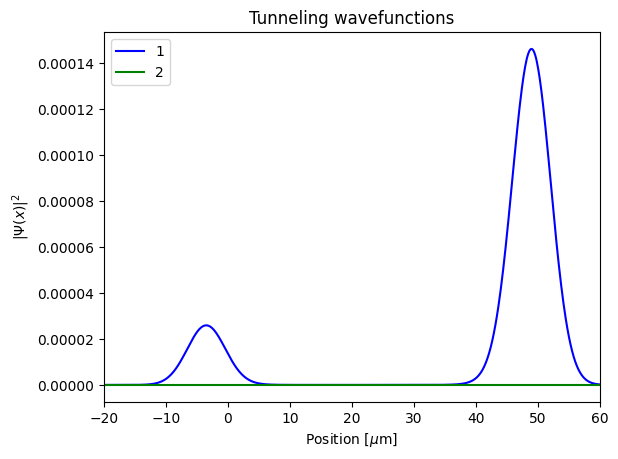

In [107]:
# Plot the wavefunctions 
index = -1
# plt.plot(X * length_scale * 1e6, np.real(psi_tun[0][index]*np.conj(psi_tun[0][index])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_tun[1][index]*np.conj(psi_tun[1][index])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_tun[2][index]*np.conj(psi_tun[2][index])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi(x)|^2$')
plt.xlim([-20,60])
plt.title("Tunneling wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

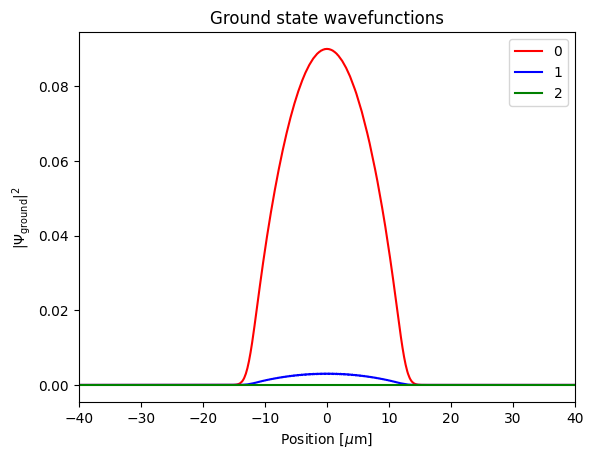

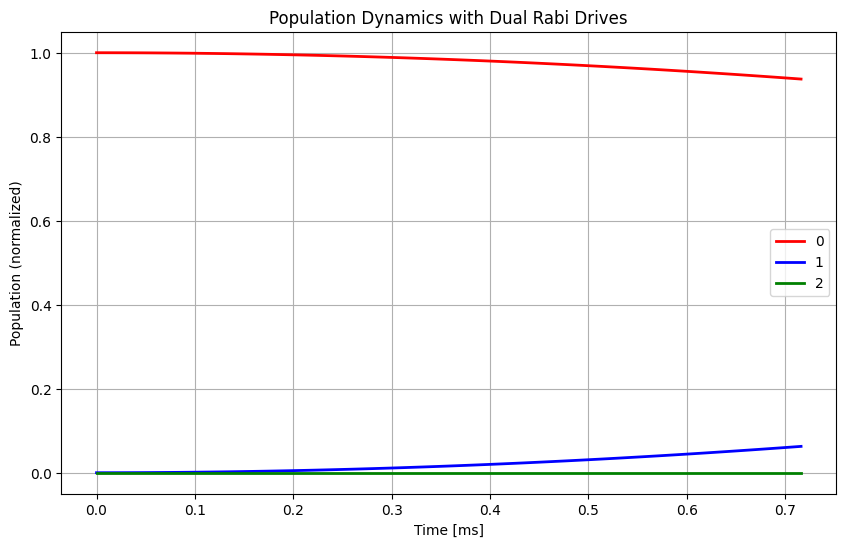

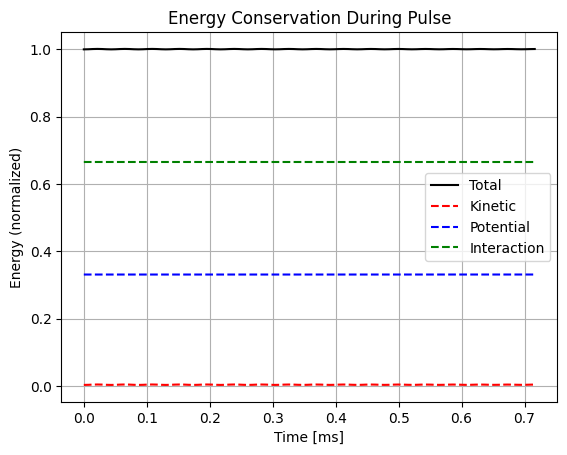

In [35]:
# Apply a pi/2 pulse to the ground state (couples components 1 and 2)
U[1] = U[0]

dt = 5e-4  # timestep spacing 
# real_time_steps = int(164e-6 / (dt * time_scale))  # total number of timesteps
real_time_steps = int(1e-3 / (dt * time_scale))

# Increase Ntstore to capture time evolution
(K_pulse1, T_pulse1, psi_pulse1, ep, energies_pulse1) = gpe1d(epsilon=epsilon, kappa=kappa_off, 
                            Omega=0, 
                            Omega_2=0,
                            N=real_time_steps, 
                            k=dt, X=X, U=U, psi0=psi_ground, Ntstore=10, 
                            imag_time=0, error=0.0002)

# Plot the wavefunctions 
plt.plot(X * length_scale * 1e6, np.real(psi_pulse1[0][-1]*np.conj(psi_pulse1[0][-1])), color='red', label="0")
plt.plot(X * length_scale * 1e6, np.real(psi_pulse1[1][-1]*np.conj(psi_pulse1[1][-1])), color='blue', label="1")
plt.plot(X * length_scale * 1e6, np.real(psi_pulse1[2][-1]*np.conj(psi_pulse1[2][-1])), color='green', label="2")
plt.xlabel(r'Position [$\mu$m]')
plt.ylabel(r'$|\Psi_{\text{ground}}|^2$')
plt.xlim([-40,40])
plt.title("Ground state wavefunctions")
# plt.axvline(27.8, color='black', linestyle='--')
plt.legend()  
plt.show()

# Calculate populations in each component as a function of time
Nt = psi_pulse1.shape[1]
pop_0 = np.zeros(Nt)
pop_1 = np.zeros(Nt)
pop_2 = np.zeros(Nt)

for t in range(Nt):
    pop_0[t] = np.sum(np.abs(psi_pulse1[0, t])**2) * dx
    pop_1[t] = np.sum(np.abs(psi_pulse1[1, t])**2) * dx
    pop_2[t] = np.sum(np.abs(psi_pulse1[2, t])**2) * dx

# Normalize populations
total_pop = pop_0 + pop_1 + pop_2
pop_0 /= total_pop
pop_1 /= total_pop
pop_2 /= total_pop

# Plot populations vs time
plt.figure(figsize=(10, 6))
plt.plot(T_pulse1 * time_scale * 1e3, pop_0, 'r-', linewidth=2, label='0')
plt.plot(T_pulse1 * time_scale * 1e3, pop_1, 'b-', linewidth=2, label='1')
plt.plot(T_pulse1 * time_scale * 1e3, pop_2, 'g-', linewidth=2, label='2')
plt.xlabel('Time [ms]')
plt.ylabel('Population (normalized)')
plt.title('Population Dynamics with Dual Rabi Drives')
plt.legend()
plt.grid(True)
plt.show()

# # Apply momentum kicks, then hold in ODT-X
# hold_time = 2.5e-3 / time_scale
# dt_hold = 5e-4
# # hold_time_steps * dt_hold * time_scale = 2.5 ms

# # Apply equal and opposite momentum kicks to the spin states
# v_kick = 8.5e-6  # m/s
# # v_kick = 10.5e-6
# k_kick = m_rb * v_kick * length_scale / hbar  # non-dimensionalized k-vector

# psi_pre_hold = np.zeros((3, len(X)), complex)
# psi_pre_hold[0] = psi_pulse1[0][-1]  # Component 0 (should be ~empty)
# psi_pre_hold[1] = psi_pulse1[1][-1] * np.exp(1j * k_kick * X)  # Component 1 gets positive kick
# psi_pre_hold[2] = psi_pulse1[2][-1] * np.exp(-1j * k_kick * X)  # Component 2 gets negative kick

# hold_time_steps = int(hold_time / dt_hold)

# # Hold in ODT-X
# (K_hold, T_hold, psi_hold, ep, energies_hold) = gpe1d(epsilon=epsilon, kappa=kappa, 
#                           Omega=0.0, Omega_2=0.0,  # No coupling during hold
#                           N=hold_time_steps, 
#                           k=dt_hold, X=X, U=U, psi0=psi_pre_hold, Ntstore=20, 
#                           imag_time=0, error=0.0002) 


# Plot energy conservation during the hold phase
plt.plot(T_pulse1 * time_scale * 1e3, energies_pulse1['total'] / energies_pulse1['total'][0], 'k-', label='Total')
plt.plot(T_pulse1 * time_scale * 1e3, energies_pulse1['kinetic'] / energies_pulse1['total'][0], 'r--', label='Kinetic')
plt.plot(T_pulse1 * time_scale * 1e3, energies_pulse1['potential'] / energies_pulse1['total'][0], 'b--', label='Potential')
plt.plot(T_pulse1 * time_scale * 1e3, energies_pulse1['interaction'] / energies_pulse1['total'][0], 'g--', label='Interaction')
plt.xlabel('Time [ms]')
plt.ylabel('Energy (normalized)')
plt.title('Energy Conservation During Pulse')
plt.legend()
plt.grid(True)
plt.show()